'/Users/jamwalk/Desktop/Research'

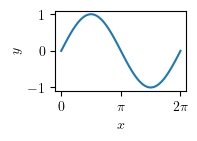

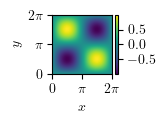

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


import sys
from pathlib import Path

here = Path.cwd()
other = here.parent.parent.parent.parent.parent.parent   # go up three
sys.path.insert(0, str(other))
from Plotting_Functions import set_font, set_fig
sys.path.pop(0)

# Lindblad / GKSL Conventions

## 1. Master equation

We use the **GKSL form**:

$$
\frac{d\rho}{dt}
=
-i[H,\rho]
+
\sum_k \gamma_k\,\mathcal{D}[L_k]\rho,
$$

where the dissipator is

$$
\boxed{
\mathcal{D}[L]\rho
=
L\rho L^\dagger
-
\frac{1}{2}\{L^\dagger L,\rho\}.
}
$$

---

## 2. Where the rates live

In this framework the rate multiplies the dissipator, not the operator.
i.e.

$$
\gamma\,\mathcal{D}[L]
\quad\text{not}\quad
\mathcal{D}[\sqrt{\gamma} L].
$$

These two are mathematically equivalent:

$$
\mathcal{D}[\sqrt{\gamma}L] = \gamma\,\mathcal{D}[L].
$$



---

## 3. Code convention

In the code:

```python
Jump(L, rate)
```

contributes $\text{rate}\times \mathcal{D}[L]$.

In [99]:
#Pauli matrices

class Pauli:
    sx = np.array([[0, 1],[1, 0]], dtype=np.complex128)
    sy = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
    sz = np.array([[1, 0],[0, -1]], dtype=np.complex128)
    I2 = np.eye(2, dtype=np.complex128)
    sp = np.array([[0, 1],[0, 0]], dtype=np.complex128)   # σ+
    sm = np.array([[0, 0],[1, 0]], dtype=np.complex128)   # σ-


#Liouvillian operators and builders
class Jump:
    def __init__(self, L: np.ndarray, rate: float):
        self.L = np.asarray(L, dtype=np.complex128)
        self.rate = float(rate)

class LindbladModel2LS:
    """
    Defines a time-dependent 2LS Lindblad model:
      H(t): 2x2
      jumps(t): list[Jump]
    """
    def __init__(self, H_of_t, jumps_of_t):
        self.H_of_t = H_of_t
        self.jumps_of_t = jumps_of_t

    def H(self, t: float) -> np.ndarray:
        return np.asarray(self.H_of_t(t), dtype=np.complex128)

    def jumps(self, t: float) -> list[Jump]:
        return list(self.jumps_of_t(t))
    

class LiouvillianBuilder:
    """
    Builds L such that d/dt vec(rho) = L vec(rho).
    Convention used:
    vec(AXB) = (B^T ⊗ A) vec(X)
    and vec uses order='F' when reshaping matrices <-> vectors.
    """
    def __init__(self, dim: int = 2, vec_order: str = "F"):
        print(dim)
        self.d = int(dim)

        self.vec_order = vec_order
        self.I = np.eye(self.d, dtype=np.complex128)

    def vec(self, X: np.ndarray) -> np.ndarray:
        return np.asarray(X, dtype=np.complex128).reshape(self.d * self.d, order=self.vec_order)

    def mat(self, x: np.ndarray) -> np.ndarray:
        return np.asarray(x, dtype=np.complex128).reshape(self.d, self.d, order=self.vec_order)

    def build(self, H: np.ndarray, jumps: list) -> np.ndarray:
        H = np.asarray(H, dtype=np.complex128)
        I = self.I

        # -i[H, ρ]
        L = -1j * (np.kron(I, H) - np.kron(H.T, I))

        for j in jumps:
            gamma = j.rate
            if gamma == 0.0:
                continue

            Lk = j.L
            LdL = Lk.conj().T @ Lk

            term_jump  = np.kron(Lk.conj(), Lk)       # L ρ L†
            term_left  = -0.5 * np.kron(I, LdL)       # -1/2 (L†L) ρ
            term_right = -0.5 * np.kron(LdL.T, I)     # -1/2 ρ (L†L)

            L += gamma * (term_jump + term_left + term_right)

        return L #note that this L is in the acts on vec(rho) space. Will not be the same as in the literature where we have the Bloch form.


# Evolution and Trajectory classes
class Trajectory:
    def __init__(self, t: np.ndarray, rho_vec: np.ndarray, builder):
        self.t = np.asarray(t, dtype=float)
        self.rho_vec = np.asarray(rho_vec, dtype=np.complex128)  # (nt, d^2)
        self._builder = builder

    def rho(self, k: int) -> np.ndarray:
        return self._builder.mat(self.rho_vec[k])

class LindbladEvolver:
    def __init__(self, model, builder):
        self.model = model
        self.builder = builder

    def simulate(self, rho0: np.ndarray, t_eval: np.ndarray, rtol=1e-9, atol=1e-12) -> Trajectory:
        rho0 = np.asarray(rho0, dtype=np.complex128)
        y0 = self.builder.vec(rho0)
        t_span = (float(t_eval[0]), float(t_eval[-1]))

        def rhs(t, y):
            H = self.model.H(t)
            jumps = self.model.jumps(t)
            L = self.builder.build(H, jumps)
            return L @ y

        sol = solve_ivp(rhs, t_span, y0, t_eval=np.asarray(t_eval, dtype=float),
                        rtol=rtol, atol=atol)

        rho_vec = sol.y.T  # (nt, d^2)
        return Trajectory(sol.t, rho_vec, self.builder)


class Biorth:
    """Biorthonormal eigensystem for L: L R = R Λ and L† W = W Λ* with W†R = I (when diagonalizable)."""
    def __init__(self):
        self.evals = None
        self.R = None
        self.W = None
        self.is_defective = False
        self.info = {}

    @staticmethod
    def compute(
        L: np.ndarray,
        *,
        tol_zero_real: float = 1e-12,
        rcond: float = 1e-12,
        allow_pinv: bool = True,
        raise_on_defective: bool = False,
    ):
        evals, R = np.linalg.eig(L)
        evalsL, V = np.linalg.eig(L.conj().T)

        # match left eigenvectors to conjugate right eigenvalues (greedy)
        W = np.zeros_like(R)
        used = np.zeros(len(evalsL), dtype=bool)
        for i, lam in enumerate(evals):
            # pick nearest not-yet-used (helps a bit with degeneracies)
            diffs = np.abs(evalsL - lam.conjugate())
            diffs = np.where(used, np.inf, diffs)
            j = int(np.argmin(diffs))
            used[j] = True
            W[:, i] = V[:, j]

        # Attempt biorthonormalization: solve W† (R X) = I  => (W†R) X = I
        M = W.conj().T @ R

        # Diagnose defectiveness / ill-conditioning
        s = np.linalg.svd(M, compute_uv=False)
        # rank estimate
        rank = int(np.sum(s > rcond * s[0])) if s.size and s[0] > 0 else 0
        cond = (s[0] / s[-1]) if (s.size and s[-1] > 0) else np.inf

        is_defective = (rank < M.shape[0]) or (not np.isfinite(cond)) or (cond > 1.0 / rcond)

        if is_defective and raise_on_defective:
            raise np.linalg.LinAlgError(
                "Biorthonormal eigenbasis does not exist / is ill-conditioned (defective or near-defective matrix). "
                "Need generalized eigenvectors (Jordan chains) instead."
            )

        if is_defective and not allow_pinv:
            # return raw (will not be biorthonormal) but at least flagged
            Rn = R
        else:
            Minv = np.linalg.pinv(M, rcond=rcond) if is_defective else np.linalg.inv(M)
            Rn = R @ Minv

        # ---- sort by real part: largest (≈0) to smallest (negative) ----
        re = evals.real
        im = evals.imag
        re0 = np.where(np.abs(re) < tol_zero_real, 0.0, re)
        order = np.lexsort((-im, np.abs(re0), -re0))

        evals = evals[order]
        Rn = Rn[:, order]
        W = W[:, order]

        out = Biorth()
        out.evals, out.R, out.W = evals, Rn, W
        out.is_defective = bool(is_defective)
        out.info = {"rank_M": rank, "cond_M": cond, "singvals_M": s}
        return out


    



def pure_rho(psi: np.ndarray, normalize: bool = True) -> np.ndarray:
    """
    Convert a state vector |psi> to density matrix rho = |psi><psi|.
    psi: shape (2,) (or (d,))
    """
    psi = np.asarray(psi, dtype=np.complex128).reshape(-1)

    if normalize:
        n = np.vdot(psi, psi)  # <psi|psi>
        if n == 0:
            raise ValueError("psi has zero norm.")
        psi = psi / np.sqrt(n)

    return np.outer(psi, psi.conj())

def trace(rho: np.ndarray) -> float:
    return float(np.real(np.trace(rho)))

def purity(rho: np.ndarray) -> float:
    return float(np.real(np.trace(rho @ rho)))

def bloch(rho: np.ndarray) -> np.ndarray:
    return np.array([
        np.real(np.trace(rho @ Pauli.sx)),
        np.real(np.trace(rho @ Pauli.sy)),
        np.real(np.trace(rho @ Pauli.sz)),
    ], dtype=float)

def supervec_rho_to_bloch(v, *, check_shape=True):
    """
    Convert a 4-supervector v = (rho00, rho01, rho10, rho11)^T
    to Bloch/Pauli coefficients b = (bI, bx, by, bz)^T where

        rho = 0.5 * (bI*I + bx*sx + by*sy + bz*sz).

    Notes:
      - Uses basis order [I, sx, sy, sz] (unnormalized Pauli basis).
      - Assumes v corresponds to the matrix entries, not Liouville-space basis states.
    """
    v = np.asarray(v)
    if check_shape and v.shape[-1] != 4:
        raise ValueError(f"Expected last dimension 4, got {v.shape}")

    rho00, rho01, rho10, rho11 = np.moveaxis(v, -1, 0)

    bI = rho00 + rho11
    bx = rho01 + rho10
    by = 1j * (rho01 - rho10)   # = Tr(sy rho)
    bz = rho00 - rho11

    return np.stack([bI, bx, by, bz], axis=-1)

#redundant function, functionality already in builder.mat
# #Convert supervec to a matrix
# def supervec_to_mat(v, *, check_shape=True):
#     """
#     Convert a 4-supervector v = (rho00, rho01, rho10, rho11)^T
#     to a 2x2 density matrix.
#     Notes:
#       - Assumes v corresponds to the matrix entries, not Liouville-space basis states.
#     """
#     v = np.asarray(v)
#     if check_shape and v.shape[-1] != 4:
#         raise ValueError(f"Expected last dimension 4, got {v.shape}")

#     rho00, rho01, rho10, rho11 = np.moveaxis(v, -1, 0)

#     return np.stack([
#         [rho00, rho10],
#         [rho01, rho11]
#     ], axis=-2) #Defined with F ordering


def bloch_to_operator(v):
    """
    Build the operator v_x σx + v_y σy + v_z σz from a 3-vector v.
    v can be length-3 array-like.
    Returns a 2x2 complex ndarray.
    """
    v = np.asarray(v, dtype=float).ravel()
    if v.size != 3:
        raise ValueError("Expected v of length 3 (bx,by,bz).")
    return v[0] * Pauli.sx + v[1] * Pauli.sy + v[2] * Pauli.sz
    

In [51]:
def get_steady_state(builder, model, t: float, *, normalize_trace: bool = True, return_eval: bool = False):
    """
    Compute the instantaneous steady-state density matrix for the Lindbladian
    L(t) = builder.build(model.H(t), model.jumps(t)).

    Strategy:
      - diagonalise L(t)
      - pick the eigenvector whose eigenvalue has smallest absolute value
        (closest to zero steady-state)
      - reshape to matrix via builder.mat and optionally normalise trace -> 1

    Parameters
    ----------
    builder : LiouvillianBuilder
        Builder used to vectorise/unvectorise states and to build L.
    model : LindbladModel2LS (or compatible object)
        Must provide model.H(t) and model.jumps(t).
    t : float
        Time at which to evaluate the instantaneous steady state.
    normalize_trace : bool, optional
        If True (default) normalise returned rho so trace(rho)=1 when possible.
    return_eval : bool, optional
        If True also return the eigenvalue associated with the returned eigenvector.

    Returns
    -------
    rho_ss : ndarray (d,d)
        Instantaneous steady-state density matrix (not guaranteed strictly positive
        due to numerical error).
    eval_ss : complex, optional
        If return_eval is True, also return the corresponding eigenvalue.
    """
    # Build Liouvillian at time t
    L = builder.build(model.H(t), model.jumps(t))

    # Diagonalise
    evals, R = np.linalg.eig(L)

    # pick eigenvector with eigenvalue closest to zero
    idx = int(np.argmin(np.abs(evals)))
    vec = R[:, idx]

    # reshape to matrix (builder.mat uses vec_order set on the builder)
    rho_ss = builder.mat(vec)

    # normalise trace if requested and possible
    if normalize_trace:
        tr = np.trace(rho_ss)
        if np.abs(tr) > 0:
            rho_ss = rho_ss / tr

    if return_eval:
        return rho_ss, evals[idx]
    return rho_ss

def get_steady_state_zz_of_t(builder, model, t: np.ndarray):
    """
    Compute the instantaneous steady-state prediction for <σz> at times t.
    """
    sz_ss_t = np.zeros_like(t, dtype=float)
    for i, tt in enumerate(t):
        rho_ss = get_steady_state(builder, model, tt)
        sz_ss_t[i] = np.real(np.trace(rho_ss @ Pauli.sz))
    return sz_ss_t


def get_steady_state_blochvector_of_t(builder, model, t):
    """
    Compute the instantaneous steady-state Bloch vector [bx, by, bz] at times t.

    Returns:
      b_t : np.ndarray shaped (nt, 3) with columns [bx, by, bz] (dtype=float)
    """
    t = np.asarray(t, dtype=float)
    b_t = np.zeros((t.size, 3), dtype=float)
    for i, tt in enumerate(t):
        rho_ss = get_steady_state(builder, model, float(tt))
        # defensive: ensure rho_ss is a matrix
        rho_ss = np.asarray(rho_ss, dtype=np.complex128)
        b_t[i] = bloch(rho_ss)  # uses existing helper: returns [bx, by, bz]
    return b_t

def run_2ls_lindblad_protocol(
    tmax: float,
    epsilon_of_t,
    gamma_of_t,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
):
    """
    Run a 2LS Lindblad simulation with time-dependent rates:
        dρ/dt = -i[ (ω/2)σz , ρ ] + ε(t) D[σ-]ρ + γ(t) D[σx]ρ

    Returns: (t, traj, s_t, sz_ss_t)
      - t:      time grid (nt,)
      - traj:   Trajectory object from your evolver
      - s_t:    Bloch components (nt,3) = <σx>,<σy>,<σz>
      - sz_ss_t instantaneous steady-state prediction for <σz> (nt,)
    """
    # Default initial state: |+x><+x|
    if rho0 is None:
        rho0 = pure_rho(np.array([1.0/np.sqrt(2), 1.0/np.sqrt(2)]), normalize=True)

    # Model definitions
    def H_of_t(t):
        return 0.5 * omega * Pauli.sz

    def jumps_of_t(t):
        eps = float(epsilon_of_t(t))
        gam = float(gamma_of_t(t))
        return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Evolve
    traj = evolver.simulate(rho0, t)

    # Bloch vector time series
    s_t = np.array([bloch(traj.rho(k)) for k in range(len(traj.t))])  # (nt,3)

    # Evaluate epsilon(t), gamma(t) on the grid robustly (vectorized if possible)
    def eval_on_grid(f, grid):
        try:
            out = f(grid)
            out = np.asarray(out, dtype=float)
            if out.shape == grid.shape:
                return out
        except Exception:
            pass
        return np.array([float(f(tt)) for tt in grid], dtype=float)

    eps_t = eval_on_grid(epsilon_of_t, t)
    gam_t = eval_on_grid(gamma_of_t, t)

    # Instantaneous steady-state prediction for <σz>
    # (Assumes the same convention we derived for Jump(σ-, ε) and Jump(σx, γ))
    sz_ss_t = -eps_t / (eps_t + 2.0 * gam_t)

    # Plot
    if do_plot:
        set_font(20)
        set_fig(2.0, 1.5)
        plt.title(r"$\sigma$ expectation value")
        plt.plot(t, s_t)
        plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
        plt.xlabel("Time")
        plt.ylabel(r"$\langle \sigma \rangle$")

        plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
        #plt.legend()

    return t, traj, s_t, sz_ss_t

# 1. Plotting Instantaneous Steady State
We start out by making sure that we have the plots of the instantaneous steady state correct as we would like them.

The model we want to study initially is the following simple case:
$$\mathcal{L}_s=\gamma_+(s)\mathcal{D}[\sigma^+] + \gamma_-(s)\mathcal{D}[\sigma^-],$$
where $s(t)$ depends generically on time.

2


(array([0.00000e+00, 5.50000e-03, 1.10000e-02, ..., 1.09890e+01,
        1.09945e+01, 1.10000e+01]),
 array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.50421918e-05],
        [0.00000000e+00, 0.00000000e+00, 5.98405485e-05],
        ...,
        [0.00000000e+00, 0.00000000e+00, 9.99649555e-01],
        [0.00000000e+00, 0.00000000e+00, 9.99651292e-01],
        [0.00000000e+00, 0.00000000e+00, 9.99653021e-01]]),
 array([-2.22044605e-16,  2.74999307e-03,  5.49994454e-03, ...,
         9.99966228e-01,  9.99966413e-01,  9.99966597e-01]))

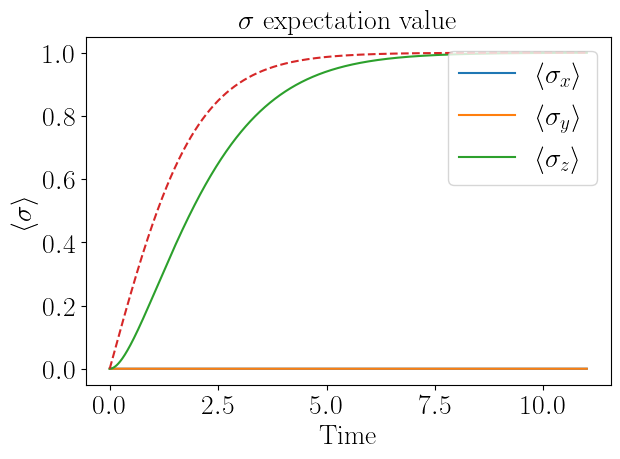

In [45]:
def ztugofwar(
    tmax: float,
    gammap_of_t,
    gammam_of_t,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
):
    """
    Run a 2LS Lindblad simulation with time-dependent rates:
        dρ/dt = -i[ (ω/2)σz , ρ ] + ε(t) D[σ-]ρ + γ(t) D[σx]ρ

    Returns: (t, traj, s_t, sz_ss_t)
      - t:      time grid (nt,)
      - traj:   Trajectory object from your evolver
      - s_t:    Bloch components (nt,3) = <σx>,<σy>,<σz>
      - sz_ss_t instantaneous steady-state prediction for <σz> (nt,)
    """
    # Default initial state: |+x><+x|
    if rho0 is None:
        rho0 = pure_rho(np.array([0.0, 1.0]), normalize=True)

    # Model definitions
    def H_of_t(t):
        return 0.0*Pauli.sz

    def jumps_of_t(t):
        gamp = float(gammap_of_t(t))
        gamm = float(gammam_of_t(t))
        return [Jump(Pauli.sm, gamm), Jump(Pauli.sp, gamp)]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Evolve
    traj = evolver.simulate(rho0, t)

    # Bloch vector time series
    s_t = np.array([bloch(traj.rho(k)) for k in range(len(traj.t))])  # (nt,3)

    # Evaluate epsilon(t), gamma(t) on the grid robustly (vectorized if possible)
    def eval_on_grid(f, grid):
        try:
            out = f(grid)
            out = np.asarray(out, dtype=float)
            if out.shape == grid.shape:
                return out
        except Exception:
            pass
        return np.array([float(f(tt)) for tt in grid], dtype=float)

    gamm_t = eval_on_grid(gammam_of_t, t)
    gamp_t = eval_on_grid(gammap_of_t, t)

    # Instantaneous steady-state prediction for <σz>
    # (Assumes the same convention we derived for Jump(σ-, γ-) and Jump(σ+, γ+))
    #sz_ss_t = (gamp_t-gamm_t)/(gamp_t+gamm_t) (Explicit expression)
    
    sz_ss_t =get_steady_state_zz_of_t(builder, model, t)

    # Plot
    if do_plot:
        set_font(20)
        set_fig(2.0, 1.5)
        plt.title(r"$\sigma$ expectation value")
        plt.plot(t, s_t)
        plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
        plt.xlabel("Time")
        plt.ylabel(r"$\langle \sigma \rangle$")

        plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
        #plt.legend()

    return t, traj, s_t, sz_ss_t


tmax=11.0
ztugofwar(
    tmax=tmax,
    gammap_of_t=lambda t: 1.0,
    gammam_of_t=lambda t: np.exp(-t),
    nsteps=2001,
    do_plot=True,
    rho0=1/2*np.array([[1.0, 0.0],[0.0, 1.0]])
)


# 2 CD Driving
We've solved for this explicitly, and it should be easy in this case to just add it on.

2


(array([0.00000e+00, 1.35000e-02, 2.70000e-02, ..., 2.69730e+01,
        2.69865e+01, 2.70000e+01]),
 array([[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.00674974],
        [0.        , 0.        , 0.01349885],
        ...,
        [0.        , 0.        , 1.        ],
        [0.        , 0.        , 1.        ],
        [0.        , 0.        , 1.        ]]),
 array([-2.22044605e-16,  6.74989749e-03,  1.34991799e-02, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00]),
 array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 8.99084411e-05],
        [0.00000000e+00, 0.00000000e+00, 3.54874772e-04],
        ...,
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]))

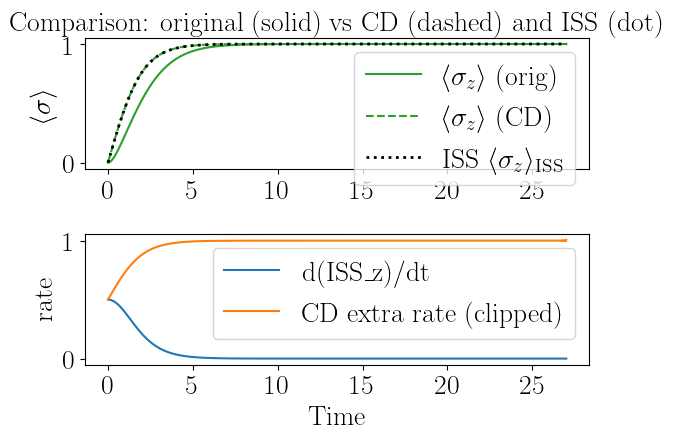

In [48]:
def ztugofwarCD(
    tmax: float,
    gammap_of_t,
    gammam_of_t,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
    apply_cd: bool = True,
    denom_tol: float = 1e-12,
):
    """
    Run a 2LS Lindblad simulation and a counterdiabatic (CD) variant.

    The CD correction adds the dissipator term:
        rate_cd(t) * D[sigma^+]  with  rate_cd(t) = (d/dt sz_ss(t)) / (1 - sz_ss(t)).

    This function keeps the original model untouched and builds a separate
    `model_cd` where the extra jump is added. It returns results for the CD
    evolution (and computes the instantaneous steady-state sz_ss_t used to build
    the CD term).

    Returns: (t, traj_cd, s_t_cd, sz_ss_t, traj_orig, s_t_orig)
      - t:      time grid (nt,)
      - traj_cd: Trajectory object for the CD model
      - s_t_cd:  Bloch components (nt,3) for CD evolution
      - sz_ss_t: instantaneous steady-state prediction for <σz> (nt,)
      - traj_orig, s_t_orig: original evolution and Bloch series (kept for comparison)
    """
    # Default initial state: |+x><+x|
    if rho0 is None:
        rho0 = pure_rho(np.array([0.0, 1.0]), normalize=True)

    # ---------------------- original model ----------------------
    def H_of_t(t):
        return 0.0 * Pauli.sz

    def jumps_of_t(t):
        gamp = float(gammap_of_t(t))
        gamm = float(gammam_of_t(t))
        return [Jump(Pauli.sm, gamm), Jump(Pauli.sp, gamp)]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Evolve original model (kept for comparison)
    traj_orig = evolver.simulate(rho0, t)
    s_t_orig = np.array([bloch(traj_orig.rho(k)) for k in range(len(traj_orig.t))])  # (nt,3)

    # Instantaneous steady-state prediction for <σz> (on the grid)
    sz_ss_t = get_steady_state_zz_of_t(builder, model, t)

    # If CD not requested, simply return original results
    if not apply_cd:
        if do_plot:
            set_font(20)
            set_fig(2.0, 1.5)
            plt.title(r"$\sigma$ expectation value (original)")
            plt.plot(t, s_t_orig)
            plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
            plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
            plt.xlabel("Time")
            plt.ylabel(r"$\langle \sigma \rangle$")
        return t, traj_orig, s_t_orig, sz_ss_t, traj_orig, s_t_orig

    # Compute time derivative of sz_ss_t on the grid
    dsz_dt = np.gradient(sz_ss_t, t)

    # Interpolators (use numpy.interp for speed and simplicity)
    def interp_sz(tval):
        return float(np.interp(tval, t, sz_ss_t))

    def interp_dsz(tval):
        return float(np.interp(tval, t, dsz_dt))

    # Build CD model (keep original model untouched)
    def jumps_of_t_cd(tval):
        gamp = float(gammap_of_t(tval))
        gamm = float(gammam_of_t(tval))

        # compute extra CD rate safely
        sz_now = interp_sz(tval)
        dsz_now = interp_dsz(tval)
        denom = (1.0 - sz_now)
        if abs(denom) < denom_tol:
            # avoid division by zero; do not apply large unphysical rate
            extra = 0.0
        else:
            extra = dsz_now / denom
            # physical rates must be non-negative; clip small negatives to zero
            if extra < 0.0:
                # small numerical negative -> set zero; large negative might indicate formula mismatch
                if extra < -1e-12:
                    print(f"Warning: computed CD rate negative ({extra:.3e}) at t={tval:.3e}; clipping to 0")
                extra = 0.0

        return [Jump(Pauli.sm, gamm), Jump(Pauli.sp, gamp + extra)]

    model_cd = LindbladModel2LS(H_of_t, jumps_of_t_cd)
    evolver_cd = LindbladEvolver(model_cd, builder)

    # Simulate CD model
    traj_cd = evolver_cd.simulate(rho0, t)
    s_t_cd = np.array([bloch(traj_cd.rho(k)) for k in range(len(traj_cd.t))])  # (nt,3)

    # Plot comparison
    if do_plot:
        plt.subplot(2,1,1)
        plt.title(r"Comparison: original (solid) vs CD (dashed) and ISS (dot)")
        # plot original
        #plt.plot(t, s_t_orig[:,0], color='C0', label=r"$\langle \sigma_x \rangle$ (orig)")
        #plt.plot(t, s_t_orig[:,1], color='C1', label=r"$\langle \sigma_y \rangle$ (orig)")
        plt.plot(t, s_t_orig[:,2], color='C2', label=r"$\langle \sigma_z \rangle$ (orig)")
        # plot CD (dashed)
        #plt.plot(t, s_t_cd[:,0], '--', color='C0', label=r"$\langle \sigma_x \rangle$ (CD)")
        #plt.plot(t, s_t_cd[:,1], '--', color='C1', label=r"$\langle \sigma_y \rangle$ (CD)")
        plt.plot(t, s_t_cd[:,2], '--', color='C2', label=r"$\langle \sigma_z \rangle$ (CD)")
        plt.plot(t, sz_ss_t, ':', color='k', linewidth=2, label=r"ISS $\langle \sigma_z \rangle_{\rm ISS}$")
        plt.legend(loc='upper right')
        plt.ylabel(r"$\langle \sigma \rangle$")

        plt.subplot(2,1,2)
        plt.plot(t, np.gradient(sz_ss_t, t), label=r"d(ISS_z)/dt")
        # compute and plot extra rate applied
        extra_rate = np.array([max(0.0, np.interp(tt, t, dsz_dt) / max(denom_tol, (1.0 - np.interp(tt, t, sz_ss_t)))) if abs(1.0 - np.interp(tt, t, sz_ss_t))>=denom_tol else 0.0 for tt in t])
        plt.plot(t, extra_rate, label=r"CD extra rate (clipped)")
        plt.xlabel("Time")
        plt.ylabel("rate")
        plt.legend()
        plt.tight_layout()

    return t, traj_cd, s_t_cd, sz_ss_t, traj_orig, s_t_orig

tmax=27.0
ztugofwarCD(
    tmax=tmax,
    gammap_of_t=lambda t: 1.0,
    gammam_of_t=lambda t: np.exp(-t),
    nsteps=2001,
    do_plot=True,
    apply_cd=True,
    rho0=1/2*np.array([[1.0, 0.0],[0.0, 1.0]])
)


Example where the protocol causes it to break since it would require negative rates for the current gauge choice of the CD AGP.

2


(array([0.00000e+00, 1.35000e-02, 2.70000e-02, ..., 2.69730e+01,
        2.69865e+01, 2.70000e+01]),
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -8.99084411e-05],
        [ 0.00000000e+00,  0.00000000e+00, -3.54874772e-04],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00]]),
 array([-2.22044605e-16, -6.74989749e-03, -1.34991799e-02, ...,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00]),
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -8.99084411e-05],
        [ 0.00000000e+00,  0.00000000e+00, -3.54874772e-04],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00]]))

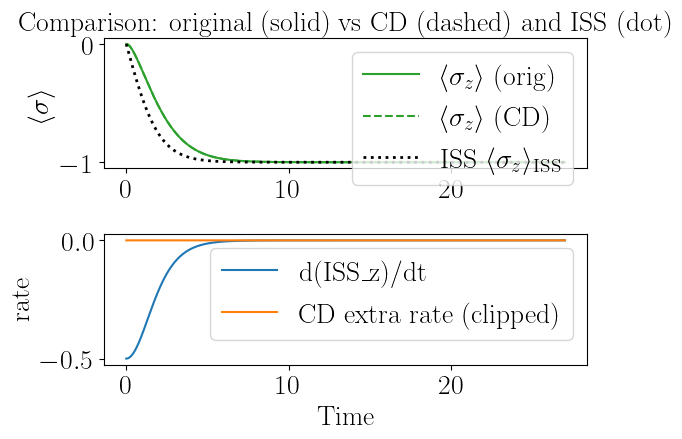

In [50]:
tmax=27.0
ztugofwarCD(
    tmax=tmax,
    gammap_of_t=lambda t: np.exp(-t),
    gammam_of_t=lambda t: 1.0,
    nsteps=2001,
    do_plot=True,
    apply_cd=True,
    rho0=1/2*np.array([[1.0, 0.0],[0.0, 1.0]])
)

## Generic CD Driving for 2LS OQS AGP ISS
Need to handle rotation, then dissipative part.

In [52]:
def normalize_rows(v, eps=1e-14):
    norms = np.linalg.norm(v, axis=1, keepdims=True)
    if np.any(norms < eps):
        raise ValueError("At least one vector has near-zero norm.")
    return v / norms


def derivative_unit_vectors_uniform(n_ss_t, dt):
    """
    Stable derivative of a time series of unit Bloch vectors.

    Parameters
    ----------
    n_ss_t : array, shape (Nt, 3)
        List/array of Bloch directions.
    dt : float
        Uniform time spacing.

    Returns
    -------
    ndot : array, shape (Nt, 3)
        Tangent-projected derivative d n / dt.
    """
    n = normalize_rows(np.asarray(n_ss_t, dtype=float))

    ndot = np.empty_like(n)

    # second-order central differences in the bulk
    ndot[1:-1] = (n[2:] - n[:-2]) / (2 * dt)

    # second-order one-sided differences at the endpoints
    ndot[0] = (-3*n[0] + 4*n[1] - n[2]) / (2 * dt)
    ndot[-1] = (3*n[-1] - 4*n[-2] + n[-3]) / (2 * dt)

    # project onto tangent plane: remove radial component
    radial = np.sum(n * ndot, axis=1, keepdims=True)
    ndot = ndot - radial * n

    return ndot

In [138]:
def LindbladISSCD(
    tmax: float,
    H_of_t,
    jumps_of_t,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
    apply_cd: bool = True,
    blochball: bool = False,
    denom_tol: float = 1e-12,
):
    """
    Run a 2LS Lindblad simulation and a counterdiabatic (CD) variant.

    The CD correction adds a Hamiltonian and dissipator term designed to keep the system close to the instantaneous steady state (ISS) of the original model. 

    This function keeps the original model untouched and builds a separate
    `model_cd` where the extra jump is added. It returns results for the CD
    evolution (and computes the instantaneous steady-state sz_ss_t used to build
    the CD term).

    Returns: (t, traj_cd, s_t_cd, sz_ss_t, traj_orig, s_t_orig)
      - t:      time grid (nt,)
      - traj_cd: Trajectory object for the CD model
      - s_t_cd:  Bloch components (nt,3) for CD evolution
      - sz_ss_t: instantaneous steady-state prediction for <σz> (nt,)
      - traj_orig, s_t_orig: original evolution and Bloch series (kept for comparison)
    """
    
    # ---------------------- original model ----------------------

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)




    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Instantaneous steady-state prediction for Bloch vector
    sz_ss_t = get_steady_state_zz_of_t(builder, model, t)
    n_ss_t = get_steady_state_blochvector_of_t(builder, model, t) #Steady state Bloch vector
    nhat_ss_t = normalize_rows(n_ss_t) #Unit Bloch vector
    nhatdot_ss_t = derivative_unit_vectors_uniform(nhat_ss_t, t[1]-t[0]) #Stable time derivative of unit Bloch vector

    if rho0 is None:
        rho0=get_steady_state(builder, model, t[0]) # start in ISS at t=0


    # Evolve original model (kept for comparison)
    traj_orig = evolver.simulate(rho0, t)
    s_t_orig = np.array([bloch(traj_orig.rho(k)) for k in range(len(traj_orig.t))])  # (nt,3)

    

    # If CD not requested, simply return original results
    if not apply_cd:
        if do_plot:
            set_font(20)
            set_fig(2.0, 1.5)
            plt.title(r"$\sigma$ expectation value (original)")
            plt.plot(t, s_t_orig)
            plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
            plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
            plt.xlabel("Time")
            plt.ylabel(r"$\langle \sigma \rangle$")
        return t, traj_orig, s_t_orig, traj_orig, s_t_orig

    def H_of_t_cd(tval):
        # total CD Hamiltonian term for counter rotation
        return H_of_t(tval)+0.5 * bloch_to_operator(np.cross(nhat_ss_t[np.searchsorted(t, tval)], nhatdot_ss_t[np.searchsorted(t, tval)]))

    # Build CD model (keep original model untouched)
    def jumps_of_t_cd(tval):
        return jumps_of_t(tval)

    model_cd = LindbladModel2LS(H_of_t_cd, jumps_of_t_cd)
    evolver_cd = LindbladEvolver(model_cd, builder)

    # Simulate CD model
    traj_cd = evolver_cd.simulate(rho0, t)
    s_t_cd = np.array([bloch(traj_cd.rho(k)) for k in range(len(traj_cd.t))])  # (nt,3)

    
    # Plot comparison
    if do_plot:
        def normalize_trajectory(s_t, eps=1e-14):
            s_t = np.asarray(s_t, dtype=float)
            norms = np.linalg.norm(s_t, axis=1, keepdims=True)
            out = np.full_like(s_t, np.nan)
            good = norms[:, 0] > eps
            out[good] = s_t[good] / norms[good]
            return out

        # Normalize all Bloch trajectories to unit vectors
        shat_t_orig = normalize_trajectory(s_t_orig)
        shat_t_cd   = normalize_trajectory(s_t_cd)
        nhat_t_ss   = normalize_trajectory(n_ss_t)

        plt.subplot(2, 1, 1)
        plt.title(r"Direction tracking on Bloch sphere (normalized vectors)")

        # original
        plt.plot(t, shat_t_orig[:, 0], color='C0', label=r"$\hat s_x$ (orig)")
        plt.plot(t, shat_t_orig[:, 1], color='C1', label=r"$\hat s_y$ (orig)")
        plt.plot(t, shat_t_orig[:, 2], color='C2', label=r"$\hat s_z$ (orig)")

        # CD
        plt.plot(t, shat_t_cd[:, 0], '--', color='C0', label=r"$\hat s_x$ (CD)")
        plt.plot(t, shat_t_cd[:, 1], '--', color='C1', label=r"$\hat s_y$ (CD)")
        plt.plot(t, shat_t_cd[:, 2], '--', color='C2', label=r"$\hat s_z$ (CD)")

        # ISS direction
        plt.plot(t, nhat_t_ss[:, 0], ':', color='C0', linewidth=2, label=r"$\hat n_{x,\rm ISS}$")
        plt.plot(t, nhat_t_ss[:, 1], ':', color='C1', linewidth=2, label=r"$\hat n_{y,\rm ISS}$")
        plt.plot(t, nhat_t_ss[:, 2], ':', color='C2', linewidth=2, label=r"$\hat n_{z,\rm ISS}$")

        plt.legend(loc='upper right', fontsize=9)
        plt.ylabel("normalized component")

        # Angular tracking error
        def angular_error_from_unit_vectors(a_t, b_t):
            dots = np.sum(a_t * b_t, axis=1)
            dots = np.clip(dots, -1.0, 1.0)
            return np.arccos(dots)

        theta_orig = angular_error_from_unit_vectors(shat_t_orig, nhat_t_ss)
        theta_cd   = angular_error_from_unit_vectors(shat_t_cd, nhat_t_ss)

        plt.subplot(2, 1, 2)
        plt.plot(t, theta_orig, color='k', label=r"$\theta_{\rm orig}(t)$")
        plt.plot(t, theta_cd, '--', color='C3', linewidth=2, label=r"$\theta_{\rm CD}(t)$")
        plt.xlabel("Time")
        plt.ylabel(r"angle to ISS [rad]")
        plt.legend()
        plt.tight_layout()

        # Extra Bloch-sphere comparison plot
    if blochball:
        plot_bloch_sphere_comparison(
            s_t_orig,
            s_t_cd,
            n_ss_t,
            t=t,
            normalize=False,
            title="Bloch-sphere trajectory: original vs CD vs ISS",
        )

    return t, traj_cd, s_t_cd, sz_ss_t, traj_orig, s_t_orig

2


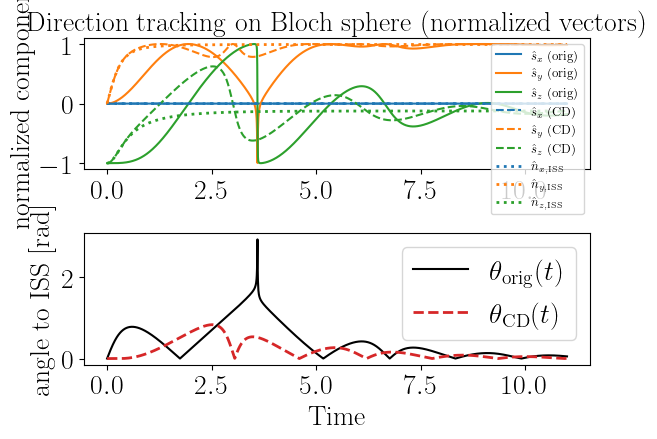

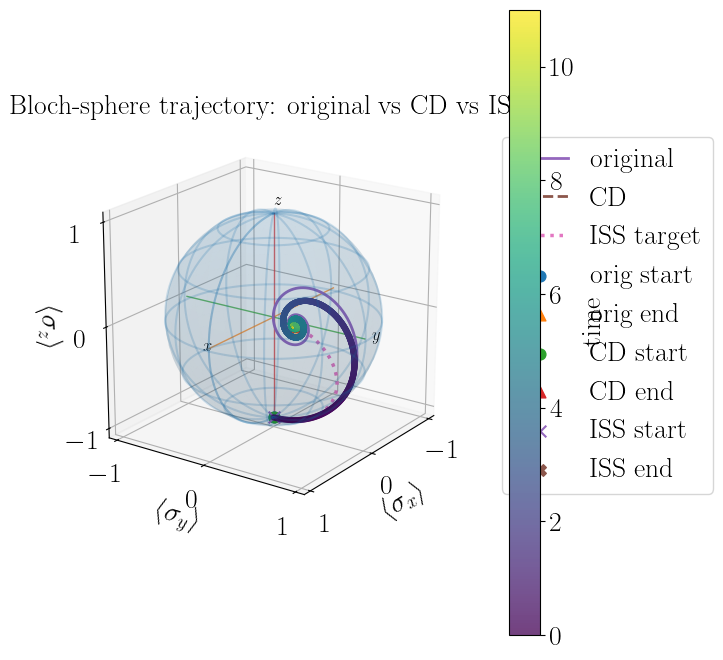

(array([0.00000e+00, 5.50000e-03, 1.10000e-02, ..., 1.09890e+01,
        1.09945e+01, 1.10000e+01]),
 array([[ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 1.42145460e-18,  1.46881452e-02, -9.99892123e-01],
        [ 8.51683619e-18,  2.93902039e-02, -9.99568014e-01],
        ...,
        [ 1.15670885e-14,  2.50626936e-01, -3.02294337e-02],
        [ 1.16481503e-14,  2.50614347e-01, -3.01397260e-02],
        [ 1.21689112e-14,  2.50600790e-01, -3.00504075e-02]]),
 array([-1.        , -0.99989226, -0.99956839, ..., -0.03030601,
        -0.03030599, -0.03030598]),
 array([[ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
        [ 0.00000000e+00,  3.01532377e-05, -1.00000000e+00],
        [ 0.00000000e+00,  1.20228207e-04, -9.99999993e-01],
        ...,
        [ 0.00000000e+00,  2.48894261e-01, -4.49843065e-02],
        [ 0.00000000e+00,  2.49046119e-01, -4.48722147e-02],
        [ 0.00000000e+00,  2.49196529e-01, -4.47587697e-02]]))

In [139]:
tmax=11.0
LindbladISSCD(
    tmax=tmax,
    H_of_t=lambda t: (1-np.exp(-t))*Pauli.sx,
    jumps_of_t=lambda t: [Jump(Pauli.sm, np.exp(-t)+0.5)],
    nsteps=2001,
    do_plot=True,
    apply_cd=True,
    blochball=True,
)

# 1. Probing Adiabatic Behaviour
Here we look at the simple 2LS with bit flips and spin lowering as the noise channels. In the dashed red line, we show the instantaneous steady-state (ISS). 

In [12]:
def run_2ls_lindblad_protocol(
    tmax: float,
    epsilon_of_t,
    gamma_of_t,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
):
    """
    Run a 2LS Lindblad simulation with time-dependent rates:
        dρ/dt = -i[ (ω/2)σz , ρ ] + ε(t) D[σ-]ρ + γ(t) D[σx]ρ

    Returns: (t, traj, s_t, sz_ss_t)
      - t:      time grid (nt,)
      - traj:   Trajectory object from your evolver
      - s_t:    Bloch components (nt,3) = <σx>,<σy>,<σz>
      - sz_ss_t instantaneous steady-state prediction for <σz> (nt,)
    """
    # Default initial state: |+x><+x|
    if rho0 is None:
        rho0 = pure_rho(np.array([1.0/np.sqrt(2), 1.0/np.sqrt(2)]), normalize=True)

    # Model definitions
    def H_of_t(t):
        return 0.5 * omega * Pauli.sz

    def jumps_of_t(t):
        eps = float(epsilon_of_t(t))
        gam = float(gamma_of_t(t))
        return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Evolve
    traj = evolver.simulate(rho0, t)

    # Bloch vector time series
    s_t = np.array([bloch(traj.rho(k)) for k in range(len(traj.t))])  # (nt,3)

    # Evaluate epsilon(t), gamma(t) on the grid robustly (vectorized if possible)
    def eval_on_grid(f, grid):
        try:
            out = f(grid)
            out = np.asarray(out, dtype=float)
            if out.shape == grid.shape:
                return out
        except Exception:
            pass
        return np.array([float(f(tt)) for tt in grid], dtype=float)

    eps_t = eval_on_grid(epsilon_of_t, t)
    gam_t = eval_on_grid(gamma_of_t, t)

    # Instantaneous steady-state prediction for <σz>
    # (Assumes the same convention we derived for Jump(σ-, ε) and Jump(σx, γ))
    sz_ss_t = -eps_t / (eps_t + 2.0 * gam_t)

    # Plot
    if do_plot:
        set_font(20)
        set_fig(2.0, 1.5)
        plt.title(r"$\sigma$ expectation value")
        plt.plot(t, s_t)
        plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
        plt.xlabel("Time")
        plt.ylabel(r"$\langle \sigma \rangle$")

        plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
        #plt.legend()

    return t, traj, s_t, sz_ss_t


## a) Example 1: fixed constants to check code working

2


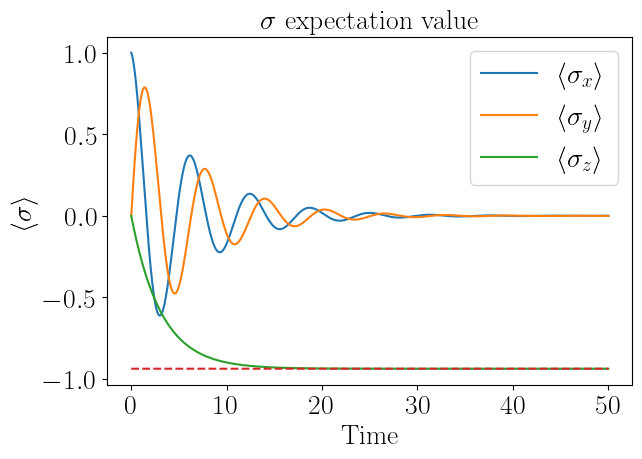

In [13]:
def epsilon_of_t(t):
    return 0.3

def gamma_of_t(t):
    return 0.01

t, traj, s_t, sz_ss_t = run_2ls_lindblad_protocol(
    tmax=50,
    epsilon_of_t=epsilon_of_t,
    gamma_of_t=gamma_of_t,
    nsteps=2001,
    do_plot=True,
)

## Example 2: Allow parameters to vary in time
In this section, we want to explore the tracking of the ISS depend on how quickly we allow different parameters to vary. We have deliberately picked the time-dependence to be relatively slow, so that we can see the tracking of the time-dependent ISS is good; after some initial transients, it appears almost perfect.

### "Slow" variation

2


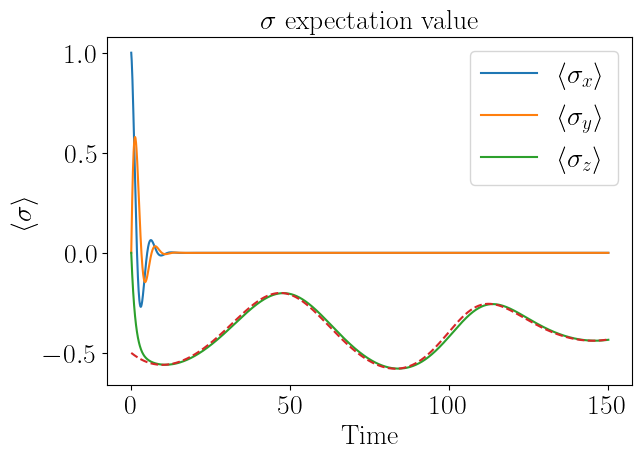

In [5]:
def epsilon_of_t(t): 
    return 0.4 + 0.2*np.sin(0.1*t) 

def gamma_of_t(t): 
    return 0.3 - 0.1*np.cos(0.07*t)

t, traj, s_t, sz_ss_t = run_2ls_lindblad_protocol(
    tmax=150,
    epsilon_of_t=epsilon_of_t,
    gamma_of_t=gamma_of_t,
    nsteps=2001,
    do_plot=True,
)

### "Fast" variation
Here we see the tracking of the ISS is extremely poor.

2


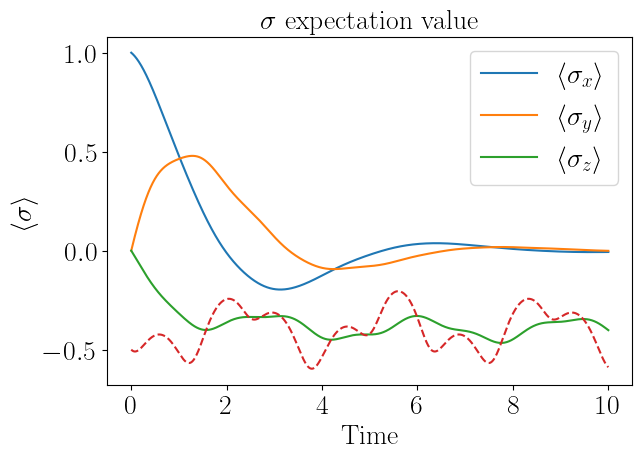

In [6]:
def epsilon_of_t(t): 
    return 0.4 + 0.2*np.sin(2*t) 

def gamma_of_t(t): 
    return 0.3 - 0.1*np.cos(5*t)

t, traj, s_t, sz_ss_t = run_2ls_lindblad_protocol(
    tmax=10,
    epsilon_of_t=epsilon_of_t,
    gamma_of_t=gamma_of_t,
    nsteps=2001,
    do_plot=True,
)

### "Fast" monotonic variation
Here we see the tracking of the ISS is extremely poor.

2


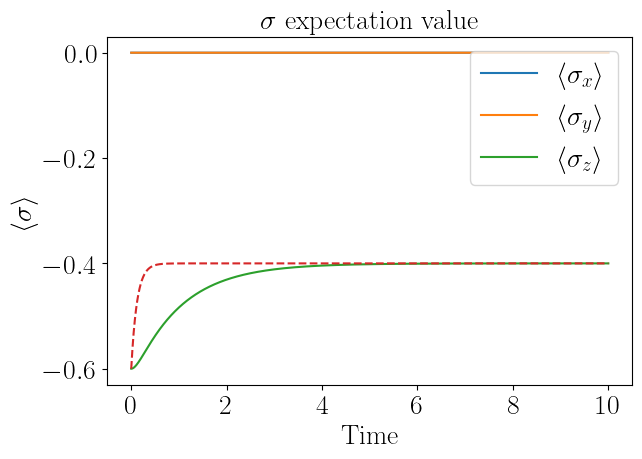

In [12]:
def epsilon_of_t(t): 
    return 0.4 + 0.2*np.exp(-8*t)

def gamma_of_t(t): 
    return 0.3 - 0.1*np.exp(-8.5*t)

rho0_ss_z= -epsilon_of_t(0) / (epsilon_of_t(0) + 2.0 * gamma_of_t(0))
rho0_ss= np.array([[0.5*(1+rho0_ss_z), 0],[0, 0.5*(1-rho0_ss_z)]], dtype=np.complex128)

t, traj, s_t, sz_ss_t = run_2ls_lindblad_protocol(
    tmax=10,
    epsilon_of_t=epsilon_of_t,
    gamma_of_t=gamma_of_t,
    rho0=rho0_ss,
    nsteps=2001,
    do_plot=True,
)

### Finding the AGP for a given ISS
We know the formula for the AGP for a unique ISS is given by
$$\mathcal{A}_s(\rho)=...$$
We want to use this formula to show in the fast example above that we track the instantaneous steady state perfectly. 

## a) Example 3: Landau-Zener inspired model
Now we have a different model which will be nice for checking the AGP at the end. In this model we use

$$H=\frac{\lambda}{2} \sigma^z+\frac{\Delta}{2}\sigma^x, \, L=\sqrt{ \gamma }\sigma^-.$$

For small dissipators, this should behave just like Landau-Zener when we eventually tune $\lambda$.

In [13]:
def run_2ls_lindblad_LZ(
    tmax: float,
    gamma_of_t,
    lambda_of_t,
    delta,
    *,
    nsteps: int = 2001,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
):
    """
    Run a 2LS Lindblad simulation with time-dependent rates:
        dρ/dt = -i[ (ω/2)σz+(∆/2)σx , ρ ] + γ(t) D[σ-]ρ

    Returns: (t, traj, s_t, sz_ss_t)
      - t:      time grid (nt,)
      - traj:   Trajectory object from your evolver
      - s_t:    Bloch components (nt,3) = <σx>,<σy>,<σz>
      - sz_ss_t instantaneous steady-state prediction for <σz> (nt,)
    """
    # Default initial state: |+x><+x|
    if rho0 is None:
        rho0 = pure_rho(np.array([1.0/np.sqrt(2), 1.0/np.sqrt(2)]), normalize=True)

    # Model definitions
    def H_of_t(t):
        return 0.5 * lambda_of_t(t) * Pauli.sz + 0.5*delta * Pauli.sx

    def jumps_of_t(t):
        gam = float(gamma_of_t(t))
        return [Jump(Pauli.sm, gam)]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    # Time grid
    t = np.linspace(0.0, float(tmax), int(nsteps))

    # Evolve
    traj = evolver.simulate(rho0, t)

    # Bloch vector time series
    s_t = np.array([bloch(traj.rho(k)) for k in range(len(traj.t))])  # (nt,3)

    # Evaluate epsilon(t), gamma(t) on the grid robustly (vectorized if possible)
    def eval_on_grid(f, grid):
        try:
            out = f(grid)
            out = np.asarray(out, dtype=float)
            if out.shape == grid.shape:
                return out
        except Exception:
            pass
        return np.array([float(f(tt)) for tt in grid], dtype=float)

    lam_t = eval_on_grid(lambda_of_t, t)
    gam_t = eval_on_grid(gamma_of_t, t)

    # Plot
    if do_plot:
        set_font(20)
        set_fig(2.0, 1.5)
        plt.title(r"$\sigma$ expectation value")
        plt.plot(t, s_t)
        plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
        plt.xlabel("Time")
        plt.ylabel(r"$\langle \sigma \rangle$")

        #plt.plot(t, sz_ss_t, "--", label=r"$\langle \sigma_z \rangle_{\rm ISS}(t)$")
        #plt.legend()

    return t, traj, s_t

### Example below explanation
In the presence of no dissipation, we do observe adiabatic tracking of the steady state (ground state in this case). This is seen by our spin expectation value pointing in the z direction by the end after we have ramped up lambda (z-field) to a ridiculous degree. It points with the field since it started in the high energy opposite state too.

If we introduce a bit of dissipation, this makes our new steady state -1. We see a sharp jump at first to the desired +1 but then dissipation takes effect.

2


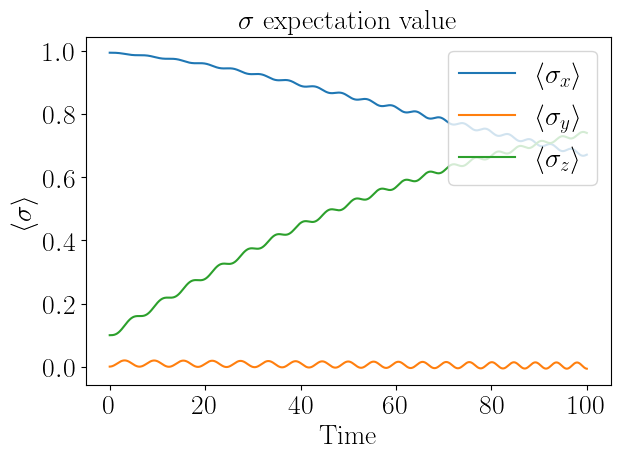

In [73]:
def lambda_of_t(t): 
    return 0.1+0.01*t

def gamma_of_t(t): 
    return 0.000

delta=1.0

H0 = 0.5 * lambda_of_t(0) * Pauli.sz + 0.5*delta * Pauli.sx
eigvals, eigvecs = np.linalg.eigh(H0)
rho0 = pure_rho(eigvecs[:,1], normalize=True)



t, traj, s_t = run_2ls_lindblad_LZ(
    tmax=100,
    gamma_of_t=gamma_of_t,
    lambda_of_t=lambda_of_t,
    rho0=rho0,
    delta=delta,
    nsteps=2001,
    do_plot=True,
)

2


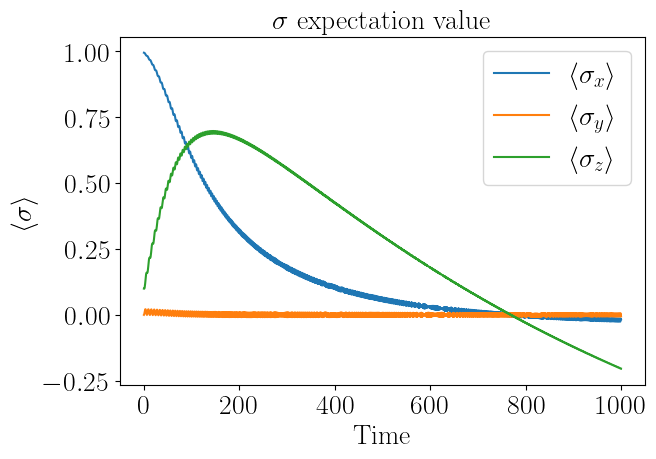

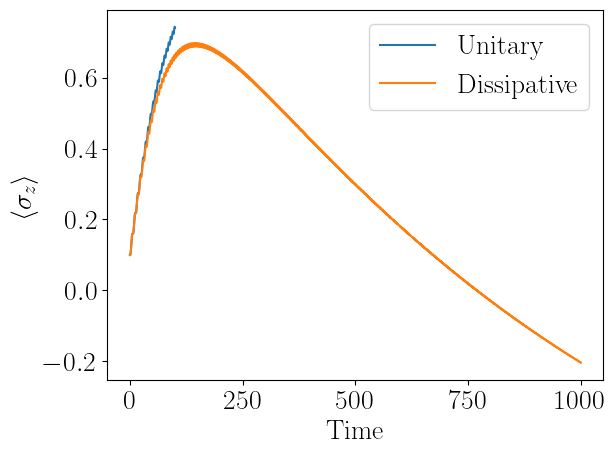

In [83]:
def gamma_of_t(t): 
    return 0.001

delta=1.0

H0 = 0.5 * lambda_of_t(0) * Pauli.sz + 0.5*delta * Pauli.sx
eigvals, eigvecs = np.linalg.eigh(H0)
rho0 = pure_rho(eigvecs[:,1], normalize=True)


#Now with the dissipator switched on
td, trajd, s_td = run_2ls_lindblad_LZ(
    tmax=1000,
    gamma_of_t=gamma_of_t,
    lambda_of_t=lambda_of_t,
    rho0=rho0,
    delta=delta,
    nsteps=2001,
    do_plot=True,
)
plt.show()


#Plot of the sigma_z w/ and w/o dissipation
plt.plot(t, s_t[:,2], label="Unitary")
plt.plot(td, s_td[:,2], label="Dissipative")
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.xlabel("Time")
plt.legend()
plt.show()

### 1. b) Look at calculating staying in an eigenstate
Define a function that gets the expectation value of the mode with respect to time.

In [487]:
try:
    from scipy.optimize import linear_sum_assignment
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
def run_2ls_lindblad_mode_protocol_time_dependent(
    tmax: float,
    epsilon_of_t,
    gamma_of_t,
    *,
    nsteps: int = 401,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
    modes: list[int] | None = None,
    eps_norm: float = 1e-15,
    occupation: str = "frac",   # NEW: "frac" or "abs"
):
    """
    Time-dependent mode decomposition with mode tracking:
      - evolve rho(t)
      - at each t_k diagonalise L(t_k) -> (evals_k, W_k, R_k) biorth basis
      - track labels by maximizing |W_prev† R_new| via assignment
      - coefficients: c_k = W_k† vec(rho_k)
      - occupation:
           "frac": |c_kj| / sum_m |c_km|
           "abs" : |c_kj|
    """
    if rho0 is None:
        rho0 = pure_rho(np.array([1.0/np.sqrt(2), 1.0/np.sqrt(2)]), normalize=True)

    def H_of_t(t): return 0.5 * omega * Pauli.sz
    def jumps_of_t(t):
        return [Jump(Pauli.sm, float(epsilon_of_t(t))), Jump(Pauli.sx, float(gamma_of_t(t)))]

    model   = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    t = np.linspace(0.0, float(tmax), int(nsteps))
    traj = evolver.simulate(rho0, t)

    nt = len(t)
    n  = dim * dim
    coeffs  = np.zeros((nt, n), dtype=np.complex128)
    evals_t = np.zeros((nt, n), dtype=np.complex128)

    def match_perm(W_prev, R_new):
        O = np.abs(W_prev.conj().T @ R_new)  # (n,n)
        if _HAS_SCIPY:
            row, col = linear_sum_assignment(-O)
            perm = col[np.argsort(row)]
            return perm
        perm = np.empty(n, dtype=int)
        used = np.zeros(n, dtype=bool)
        for i in range(n):
            j = int(np.argmax(np.where(used, -np.inf, O[i, :])))
            perm[i] = j
            used[j] = True
        return perm

    W_prev = None
    for k, tk in enumerate(t):
        Lk = builder.build(model.H(tk), model.jumps(tk))
        bi = Biorth.compute(Lk)
        Wk, Rk, evals = bi.W, bi.R, bi.evals

        if W_prev is not None:
            perm = match_perm(W_prev, Rk)
            Wk    = Wk[:, perm]
            Rk    = Rk[:, perm]
            evals = evals[perm]

        evals_t[k, :] = evals
        coeffs[k, :]  = traj.rho_vec[k, :] @ Wk.conj()
        W_prev = Wk

    absC = np.abs(coeffs)

    if occupation.lower() in ("frac", "fraction", "sum"):
        denom = np.maximum(absC.sum(axis=1, keepdims=True), eps_norm)
        occ = absC / denom
        occ_label = r"$|c_j|/\sum_k |c_k|$"
        ylab = "Fractional occupation"
    elif occupation.lower() in ("abs", "ci", "raw"):
        occ = absC
        occ_label = r"$|c_j|$"
        ylab = "Mode amplitude"
    else:
        raise ValueError(f"occupation must be 'frac' or 'abs', got {occupation!r}")

    if modes is None:
        modes = list(range(n))

    if do_plot:
        set_font(20)
        set_fig(2.3, 1.6)
        plt.title("Instantaneous mode occupations (tracked)")

        for j in modes:
            if occupation.lower() in ("frac", "fraction", "sum"):
                lab = fr"$|c_{j}|/\sum_k |c_k|$"
            else:  # "abs"/"raw"
                lab = fr"$|c_{j}|$"
            plt.plot(t, occ[:, j], label=lab)

    plt.xlabel("Time")
    plt.ylabel("Fractional occupation" if occupation.lower() in ("frac","fraction","sum") else "Mode amplitude")
    plt.legend(loc="upper right")

    # return occ in place of frac to avoid confusion, but keep old name if you prefer
    return t, traj, occ, coeffs, evals_t

In the plot below, we take $\gamma$ to vary. The associated AGP for varying this parameter only has non-zero elements between modes 1 and 2 which we calculate later. This can be seen in that we preserve the norm of 0 for all time (since it is the steady state), starting in 3 we decay but no other mode picks up any weight, and we see the mixing between 1 and 2 if we start in either. Behave exactly symmetrically which is curious. 

2
Eigenvalues at t=0: [-1.54074396e-33+0.j         -2.00000000e-02-0.99979998j
 -2.00000000e-02+0.99979998j -4.00000000e-02+0.j        ]
2


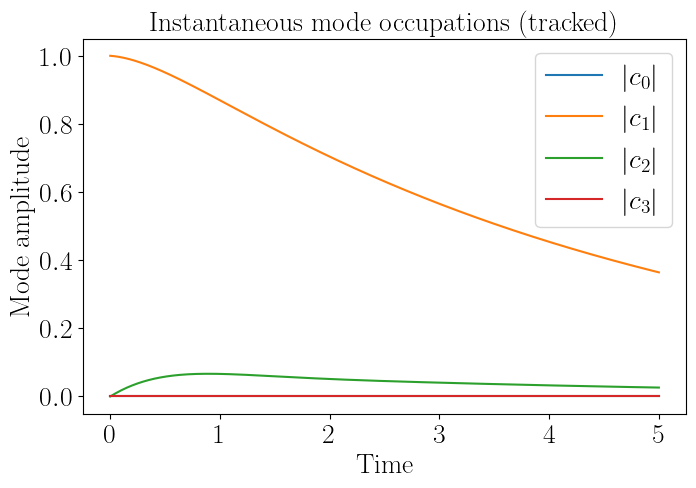

In [511]:
# Parameters
omega = 1.0
dim = 2
vec_order = "F"
T = 5  # ramp time

def epsilon_of_t(t):
    return 0.0

def gamma_of_t(t):
    return 0.2 * (1.1-np.exp(-2.0*t))#(1 - np.cos(np.pi * t / (4 * T)))

# Model definitions
def H_of_t(t):
    return 0.5 * omega * Pauli.sz

def jumps_of_t(t):
    eps = float(epsilon_of_t(t))
    gam = float(gamma_of_t(t))
    return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

model   = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)

# Build L(0) and pick initial condition from a right eigenmode at t=0
L0  = builder.build(model.H(0.0), model.jumps(0.0))
bi0 = Biorth.compute(L0)

print("Eigenvalues at t=0:", bi0.evals)
mode_idx = 1 # choose which eigenmode to start in (sorted by real part in your Biorth)
rho0 = builder.mat(bi0.R[:, mode_idx])

# OPTIONAL: fix a normalization so comparisons are meaningful across runs.
# For a decaying traceless mode, trace is usually ~0, so normalize by Frobenius norm.
nf = np.linalg.norm(rho0, 'fro')
if nf > 0:
    rho0 = rho0 / nf

# Run: gauge-invariant mode contributions
t, traj, w_occ, coeffs, evals_t = run_2ls_lindblad_mode_protocol_time_dependent(
    tmax=T,
    epsilon_of_t=epsilon_of_t,
    gamma_of_t=gamma_of_t,
    nsteps=401,
    rho0=rho0,
    omega=omega,
    dim=dim,
    vec_order=vec_order,
    do_plot=True,
    modes=[0, 1, 2, 3],
    occupation="abs",        # "abs" -> plot ||P_j x|| ; "frac" -> normalize across modes
)

# If you want the normalized fractions instead:
# occupation="frac"

# If you want to see decay-channel content of the lag relative to instantaneous steady state:
# contrib_on="delta_ss"



# t, traj, s_t, sz_ss_t = run_2ls_lindblad_protocol(
#     tmax=10,
#     epsilon_of_t=epsilon_of_t,
#     gamma_of_t=gamma_of_t,
#     nsteps=2001,
#     do_plot=True,
#     rho0=rho0
# )

In [467]:
def epsilon_of_t(t):
    return 20*(1-np.exp(-t)) # + 0.3*np.sin(0.1*t)

def gamma_of_t(t):
    return 0.4 # 0.3 - 0.3*np.sin(4*t)

# Model definitions (for building L(0) only, to pick rho0)
def H_of_t(t):
    return 0.5 * omega * Pauli.sz

def jumps_of_t(t):
    eps = float(epsilon_of_t(t))
    gam = float(gamma_of_t(t))
    return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

model   = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)

# Pick an initial condition from an instantaneous right eigenmode at t=0
L0  = builder.build(model.H(0.0), model.jumps(0.0))
bi0 = Biorth.compute(L0)

print(bi0.R[:,0])

2
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


# 2. Calculating the AGP
The form of the AGP is known for open quantum systems. Assuming that the Lindbladian is diagonalisable (not true at exceptional points w/ Jordan blocks), off-diagonal elements are calculated from
$$\mathcal{A}_{mn} = \braket{\braket{\mathcal{E}_m|\mathcal{A}_\lambda|\mathcal{D}_n}}= \frac{\braket{\braket{\mathcal{E}_m|\partial_\lambda \mathcal{L}|\mathcal{D}_n}}}{\lambda_n-\lambda_m}.$$

In our model, the exceptional point occurs at $\gamma=\omega$, so as long as we only explore above and below this, we should be able to use the above formula. For large $\gamma$, we essentially have overdamped oscillations, and for small $\gamma$ we have underdamped oscillations. 


In [128]:
class AGP:
    """
    Utility methods for computing AGP-like quantities.
    Keep this isolated: handles biorthogonal normalization and gap safeguards.
    """
    def __init__(self, gap_tol: float = 1e-10):
        self.gap_tol = float(gap_tol)

    def biorthogonal_eigs(self, L: np.ndarray):
        # Right eigs: L R = λ R
        evals, R = np.linalg.eig(L) 

        # Left eigs: L^† Lleft = λ* Lleft  <=> (L^†) V = λ* V
        evalsL, V = np.linalg.eig(L.conj().T)

        # Match eigenvalues by closest conjugate for left and right eigenvecs
        Lleft = np.zeros_like(R)
        for i, lam in enumerate(evals):
            j = int(np.argmin(np.abs(evalsL - lam.conjugate())))
            Lleft[:, i] = V[:, j]

        # Biorthonormalize: Lleft^† R = I
        M = Lleft.conj().T @ R
        Minv = np.linalg.inv(M)
        Rn = R @ Minv
        # then Lleft stays as is, but now Lleft^† Rn = I
        return evals, Rn, Lleft

    def offdiag_from_dL(self, evals, R, Lleft, dL):
        """
        Off-diagonal AGP elements in eigenbasis:
          A_{ab} = <L_a| dR_b> = <L_a| dL |R_b> / (λ_b - λ_a), a!=b
        Returns A in that eigenbasis.
        """
        n = len(evals)
        A = np.zeros((n, n), dtype=np.complex128)
        for a in range(n):
            for b in range(n):
                if a == b:
                    continue
                denom = (evals[b] - evals[a])
                if abs(denom) < self.gap_tol:
                    A[a, b] = np.nan  # signal singular/EP/degeneracy
                    continue
                num = (Lleft[:, a].conj().T @ (dL @ R[:, b]))
                A[a, b] = num / denom
        return A

In [590]:
#Parameters
omega=1.0
dim=2
vec_order="F"

#Functions for the parameters
def epsilon_of_t(t):
    return 0.0*t
def gamma_of_t(t):
    return 0.4*t+1.1


def H_of_t(t):
        return 0.5 * omega * Pauli.sz

def jumps_of_t(t):
    eps = float(epsilon_of_t(t))
    gam = float(gamma_of_t(t))
    return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

model = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)

def L_of_t(t: float) -> np.ndarray:
    H = model.H(t)
    jumps = model.jumps(t)
    return builder.build(H, jumps)

def dL_dt(t: float, dt: float = 1e-6) -> np.ndarray:
    # central finite difference
    return (L_of_t(t + dt) - L_of_t(t - dt)) / (2.0 * dt)

agp = AGP(gap_tol=1e-10)

t0 = 0.001# pick the time where you want the instantaneous AGP
L0 = L_of_t(t0)
dL0 = dL_dt(t0, dt=1e-6)
evals, Rn, Lleft = agp.biorthogonal_eigs(L0)
A_eig = agp.offdiag_from_dL(evals, Rn, Lleft, dL0)

# AGP in the ORIGINAL Liouville-space basis (same basis as L0):
A0 = Rn @ A_eig @ (Lleft.conj().T)
print(np.round(A0,3))
print(1/2*((gamma_of_t(0.1)-gamma_of_t(0))/0.1)*omega/(omega**2-gamma_of_t(t0)**2))
# sanity checks
# print("biorth check ||L†R - I||:", np.linalg.norm(Lleft.conj().T @ Rn - np.eye(len(evals))))
# print("any nans in A_eig?", np.any(np.isnan(A_eig)))
# print(np.round(A0,3))
# print(np.round(Rn, 3))
print(evals)
# #Rn[:,1]

#TK How can the AGP be used to construct counter-diabatic terms in the Lindbladian? Can we see that we stay in the ISS?

2
[[-0.+0.j     0.+0.j     0.+0.j     0.+0.j   ]
 [ 0.+0.j     0.-0.j     0.-0.948j  0.+0.j   ]
 [ 0.+0.j    -0.+0.948j -0.+0.j     0.+0.j   ]
 [-0.+0.j     0.+0.j     0.+0.j     0.+0.j   ]]
-0.9484059572033713
[-4.93038066e-32+0.00000000e+00j -2.20080000e+00+0.00000000e+00j
 -6.41183101e-01-3.27158160e-16j -1.55961690e+00+1.88380282e-16j]


### Cancelling the excitations using the AGP.
We've already seen that when we drive the system quickly, there is exchange between the modes 1 and 2. We now want to see that if we add on the appropriate counterdiabatic term, that this goes away.

In [591]:
# --- Minimal CD driving using YOUR AGP class + existing model/builder ---
# Assumes you already imported: numpy as np, solve_ivp
# Assumes you already defined: Pauli, Jump, LindbladModel2LS, LiouvillianBuilder, Trajectory, LindbladEvolver
# Assumes you already defined the code exactly as in your message: AGP, model, builder, L_of_t, dL_dt, etc.

# 1) Build instantaneous counterdiabatic superoperator LCD(t) in the SAME basis as L(t)
def LCD_of_t(t: float, *, fd_dt: float = 1e-6, zero_diag: bool = True) -> np.ndarray:
    L = L_of_t(t)
    dL = dL_dt(t, dt=fd_dt)

    evals, Rn, Lleft = agp.biorthogonal_eigs(L)
    A_eig = agp.offdiag_from_dL(evals, Rn, Lleft, dL)

    # gauge choice: remove diagonal (doesn't affect transitions, stabilizes numerics)
    if zero_diag:
        np.fill_diagonal(A_eig, 0.0)

    # handle near-degeneracies/EPs flagged by NaNs
    if np.any(np.isnan(A_eig)):
        # policy: zero the singular couplings (or raise if you prefer)
        A_eig = np.where(np.isnan(A_eig), 0.0, A_eig)

    # reconstruct in original Liouville-space basis
    LCD = Rn @ A_eig @ (Lleft.conj().T)
    return LCD


# 2) Total generator with optional CD term
def Ltot_of_t(t: float, *, use_cd: bool = True, cd_scale: float = 1.0, fd_dt: float = 1e-6) -> np.ndarray:
    L = L_of_t(t)
    if not use_cd:
        return L
    return L + cd_scale * LCD_of_t(t, fd_dt=fd_dt)


# 3) Evolver that integrates d/dt vec(rho)=Ltot(t) vec(rho) (returns your Trajectory)
def simulate_with_cd(
    rho0: np.ndarray,
    t_eval: np.ndarray,
    *,
    use_cd: bool = True,
    cd_scale: float = 1.0,
    fd_dt: float = 1e-6,
    rtol: float = 1e-9,
    atol: float = 1e-12,
) -> Trajectory:
    rho0 = np.asarray(rho0, dtype=np.complex128)
    y0 = builder.vec(rho0)
    t_span = (float(t_eval[0]), float(t_eval[-1]))

    def rhs(t, y):
        return Ltot_of_t(t, use_cd=use_cd, cd_scale=cd_scale, fd_dt=fd_dt) @ y

    sol = solve_ivp(rhs, t_span, y0, t_eval=np.asarray(t_eval, dtype=float), rtol=rtol, atol=atol)
    return Trajectory(sol.t, sol.y.T, builder)


# 4) Diagnostics: instantaneous mode coefficients c(t)=Lleft(t)† vec(rho(t))
#    This is the cleanest way to check "transitions are cancelled" in your current framework.
def instantaneous_mode_coeffs(t: float, rho: np.ndarray):
    L = L_of_t(t)
    evals, Rn, Lleft = agp.biorthogonal_eigs(L)
    c = Lleft.conj().T @ builder.vec(rho)
    return evals, c


# -------------------------
# Example run (edit rho0 as needed)

bi0 = Biorth.compute(L0)
print("Eigenvalues at t=0:", bi0.evals)
mode_idx = 1 # choose which eigenmode to start in (sorted by real part in your Biorth)
rho0 = builder.mat(bi0.R[:, mode_idx])

t_eval = np.linspace(0.001, 0.3, 601)

traj_no = simulate_with_cd(rho0, t_eval, use_cd=False)
traj_cd = simulate_with_cd(rho0, t_eval, use_cd=True, cd_scale=1.0, fd_dt=1e-6)

# Compare normalized |c_n(t)| at a few times
for t_probe in [0.001,0.05, 0.10, 0.20, 0.30]:
    k_no = int(np.argmin(np.abs(traj_no.t - t_probe)))
    k_cd = int(np.argmin(np.abs(traj_cd.t - t_probe)))

    evals_no, c_no = instantaneous_mode_coeffs(traj_no.t[k_no], traj_no.rho(k_no))
    evals_cd, c_cd = instantaneous_mode_coeffs(traj_cd.t[k_cd], traj_cd.rho(k_cd))

    occ_no = np.abs(c_no) / max(1e-16, np.sum(np.abs(c_no)))
    occ_cd = np.abs(c_cd) / max(1e-16, np.sum(np.abs(c_cd)))

    print(f"\n t = {t_probe:.2f}")
    print(" evals(t):", np.round(evals_no, 6))
    print(" occ no-CD:", np.round(occ_no, 4))
    print(" occ   CD:", np.round(occ_cd, 4))

# Inspect LCD at your earlier t0
t0 = 0.09
print("\nLCD(t0) rounded:")
print(np.round(LCD_of_t(t0, fd_dt=1e-6), 3))

# Optional: check CD term magnitude relative to L
L0 = L_of_t(t0)
LCD0 = LCD_of_t(t0)
print("\n||L||, ||LCD||, ||LCD||/||L|| at t0:",
      np.linalg.norm(L0), np.linalg.norm(LCD0), np.linalg.norm(LCD0)/max(1e-16, np.linalg.norm(L0)))
print("\nAGP(t0) in Liouville basis (rounded):\n",
      np.round(agp.offdiag_from_dL(*agp.biorthogonal_eigs(L_of_t(t0)), dL_dt(t0)), 3))



Eigenvalues at t=0: [-4.93038066e-32+0.00000000e+00j -6.41183101e-01-3.27158160e-16j
 -1.55961690e+00+1.88380282e-16j -2.20080000e+00+0.00000000e+00j]

 t = 0.00
 evals(t): [-0.      +0.j -2.2008  +0.j -0.641183-0.j -1.559617+0.j]
 occ no-CD: [0. 0. 1. 0.]
 occ   CD: [0. 0. 1. 0.]

 t = 0.05
 evals(t): [-0.      +0.j -2.239869+0.j -0.615699+0.j -1.62417 +0.j]
 occ no-CD: [0.     0.     0.9605 0.0395]
 occ   CD: [0. 0. 1. 0.]

 t = 0.10
 evals(t): [-0.      +0.j -2.280135+0.j -0.59257 -0.j -1.687565+0.j]
 occ no-CD: [0.     0.     0.9308 0.0692]
 occ   CD: [0. 0. 1. 0.]

 t = 0.20
 evals(t): [-0.      +0.j -2.359868+0.j -0.55364 -0.j -1.806228+0.j]
 occ no-CD: [0.     0.     0.8928 0.1072]
 occ   CD: [0. 0. 1. 0.]

 t = 0.30
 evals(t): [-0.      +0.j -2.44    +0.j -0.521144+0.j -1.918856+0.j]
 occ no-CD: [0.     0.     0.8718 0.1282]
 occ   CD: [0. 0. 1. 0.]

LCD(t0) rounded:
[[-0.+0.j     0.+0.j     0.+0.j     0.+0.j   ]
 [ 0.+0.j    -0.+0.j     0.-0.688j  0.+0.j   ]
 [ 0.+0.j    -0.+0

<Figure size 640x480 with 0 Axes>

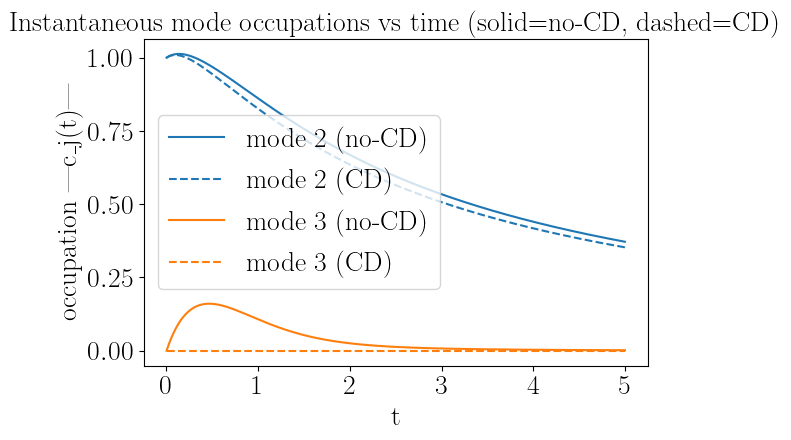

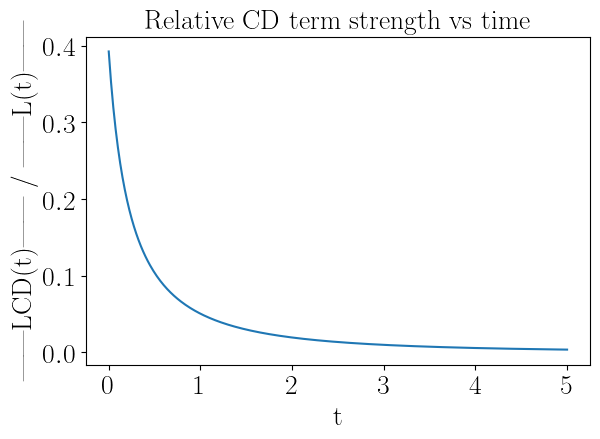

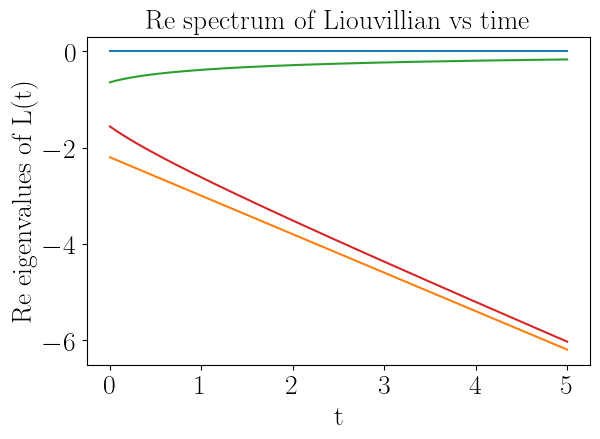

In [592]:

# Optional but recommended: robust mode tracking (fixes label swapping at crossings)
try:
    from scipy.optimize import linear_sum_assignment
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def _best_perm_from_overlap(S: np.ndarray) -> np.ndarray:
    """
    Overlap matrix S (n,n), S_ij >= 0. Return permutation p with p[i]=j maximizing sum_i S[i,p[i]].
    Hungarian if SciPy exists; greedy fallback otherwise.
    """
    n = S.shape[0]
    if _HAS_SCIPY:
        r, c = linear_sum_assignment(-S)  # maximize S == minimize -S
        p = np.zeros(n, dtype=int)
        p[r] = c
        return p

    # Greedy fallback
    Swork = S.copy()
    p = -np.ones(n, dtype=int)
    used_rows = set()
    used_cols = set()
    for _ in range(n):
        i, j = np.unravel_index(np.argmax(Swork), Swork.shape)
        while (i in used_rows) or (j in used_cols):
            Swork[i, j] = -np.inf
            i, j = np.unravel_index(np.argmax(Swork), Swork.shape)
        p[i] = j
        used_rows.add(i)
        used_cols.add(j)
        Swork[i, :] = -np.inf
        Swork[:, j] = -np.inf
    return p


# -------------------------
# Helper: compute occupations along a trajectory (WITH mode tracking)
def occupations_over_time(
    traj: Trajectory,
    *,
    occupation: str = "abs",   # "abs" or "frac"
    modes: list[int] | None = None,
    track_modes: bool = True,  # set False to revert to raw instantaneous ordering
):
    t = np.asarray(traj.t, dtype=float)
    nmodes = int(builder.vec(traj.rho(0)).shape[0])  # Liouville dimension (e.g. 4 for 2LS)

    if modes is None:
        modes = list(range(nmodes))

    occ = np.zeros((len(t), len(modes)), dtype=float)
    evals_store = np.zeros((len(t), nmodes), dtype=np.complex128)

    # Initialize previous basis for tracking
    R_prev = None
    W_prev = None

    for k, tk in enumerate(t):
        rho_k = traj.rho(k)

        L = L_of_t(float(tk))
        evals, Rn, Lleft = agp.biorthogonal_eigs(L)  # Rn: right cols, Lleft: left cols

        # --- mode tracking: reorder (evals, Rn, Lleft) to stay continuous in time
        if track_modes and (R_prev is not None) and (W_prev is not None):
            # Overlap matrix S_ij = | <W_prev_i | R_new_j> |
            S = np.abs(W_prev.conj().T @ Rn)
            p = _best_perm_from_overlap(S)

            evals = evals[p]
            Rn = Rn[:, p]
            Lleft = Lleft[:, p]

            # Re-enforce biorthonormality after permutation (safe even if already satisfied)
            M = Lleft.conj().T @ Rn
            Rn = Rn @ np.linalg.inv(M)

        # Store and update prev
        evals_store[k, :] = evals
        R_prev = Rn
        W_prev = Lleft

        # coefficients in instantaneous biorth basis
        c = Lleft.conj().T @ builder.vec(rho_k)

        amp = np.abs(c)
        if occupation == "frac":
            denom = max(1e-16, float(np.sum(amp)))
            amp = amp / denom
        elif occupation == "abs":
            pass
        else:
            raise ValueError("occupation must be 'abs' or 'frac'")

        for j, mj in enumerate(modes):
            occ[k, j] = float(amp[mj])

    return t, occ, evals_store


# -------------------------
# Helper: compute ||LCD||/||L|| over time (diagnostic)
def cd_strength_over_time(t_eval: np.ndarray, *, fd_dt: float = 1e-6):
    t_eval = np.asarray(t_eval, dtype=float)
    ratio = np.zeros_like(t_eval, dtype=float)
    nL = np.zeros_like(t_eval, dtype=float)
    nCD = np.zeros_like(t_eval, dtype=float)

    for k, tk in enumerate(t_eval):
        L = L_of_t(float(tk))
        LCD = LCD_of_t(float(tk), fd_dt=fd_dt)
        nL[k] = np.linalg.norm(L)
        nCD[k] = np.linalg.norm(LCD)
        ratio[k] = nCD[k] / max(1e-16, nL[k])

    return t_eval, nL, nCD, ratio


# -------------------------
# Run both evolutions (assumes you already defined: T, rho0, simulate_with_cd, etc.)
t_eval = np.linspace(0.001, T, 401)

traj_no = simulate_with_cd(rho0, t_eval, use_cd=False)
traj_cd = simulate_with_cd(rho0, t_eval, use_cd=True, cd_scale=1.0, fd_dt=1e-6)

# Choose which instantaneous modes to plot
modes = [0, 1, 2, 3]  # for a 2LS Liouvillian

# Occupations with tracking (prevents index swapping at crossings)
t_no, occ_no, evals_no = occupations_over_time(traj_no, occupation="abs", modes=modes, track_modes=True)
t_cd, occ_cd, evals_cd = occupations_over_time(traj_cd, occupation="abs", modes=modes, track_modes=True)

# CD strength diagnostic
t_s, nL, nCD, ratio = cd_strength_over_time(t_eval, fd_dt=1e-6)

# -------------------------
# Plot: occupations vs time (no-CD vs CD)
plt.figure()



modes_plot = [2, 3]

plt.figure()

for mj in modes_plot:
    # solid: no-CD
    (ln_solid,) = plt.plot(t_no, occ_no[:, mj], label=f"mode {mj} (no-CD)")
    col = ln_solid.get_color()

    # dashed: CD (force same color)
    plt.plot(t_cd, occ_cd[:, mj], linestyle="--", color=col, label=f"mode {mj} (CD)")

plt.xlabel("t")
plt.ylabel("occupation |c_j(t)|")
plt.title("Instantaneous mode occupations vs time (solid=no-CD, dashed=CD)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot: ||LCD||/||L|| vs time
plt.figure()
plt.plot(t_s, ratio)
plt.xlabel("t")
plt.ylabel("||LCD(t)|| / ||L(t)||")
plt.title("Relative CD term strength vs time")
plt.tight_layout()
plt.show()

# -------------------------
# Optional: plot real parts of eigenvalues vs time
plt.figure()
for j in range(evals_no.shape[1]):
    plt.plot(t_no, np.real(evals_no[:, j]))
plt.xlabel("t")
plt.ylabel("Re eigenvalues of L(t)")
plt.title("Re spectrum of Liouvillian vs time")
plt.tight_layout()
plt.show()

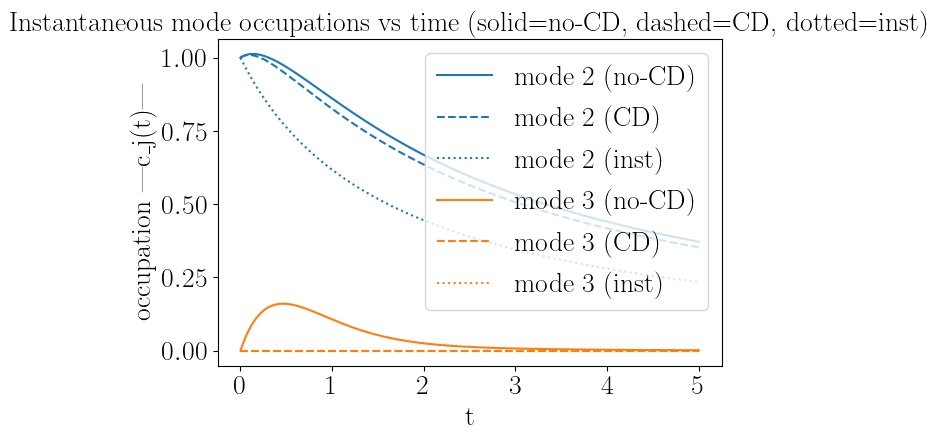

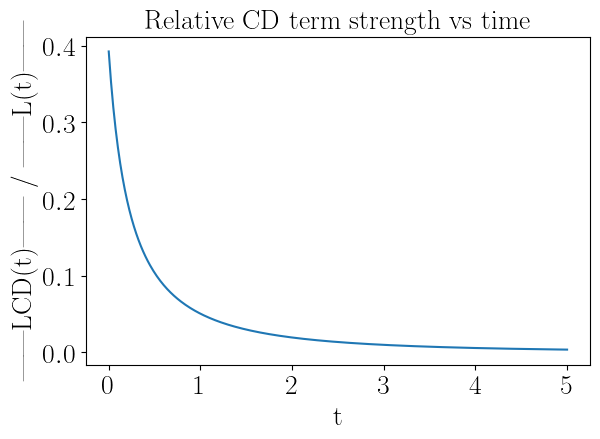

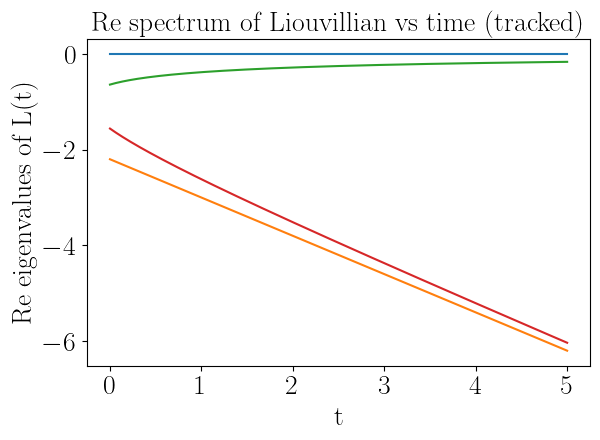

In [594]:
# -------------------------
# Run both evolutions
t_eval = np.linspace(0.001, T, 401)

traj_no = simulate_with_cd(rho0, t_eval, use_cd=False)
traj_cd = simulate_with_cd(rho0, t_eval, use_cd=True, cd_scale=1.0, fd_dt=1e-6)

# Choose which instantaneous modes to plot
modes = [0, 1, 2, 3]  # for a 2LS Liouvillian
modes_plot = [2, 3]   # change as desired

# Occupations with tracking (prevents index swapping at crossings)
t_no, occ_no, evals_no = occupations_over_time(traj_no, occupation="abs", modes=modes, track_modes=True)
t_cd, occ_cd, evals_cd = occupations_over_time(traj_cd, occupation="abs", modes=modes, track_modes=True)

# -------------------------
# Instantaneous / adiabatic prediction (should match CD when tracking is consistent)
# c_inst_j(t) = c_j(t0) * exp(∫_{t0}^t λ_j(τ) dτ)   using tracked evals_cd
t0 = float(t_cd[0])

# IMPORTANT: use the same instantaneous (untracked) basis at t0 as occupations_over_time does at k=0
L0 = L_of_t(t0)
evals0, R0, W0 = agp.biorthogonal_eigs(L0)

# initial coefficients for the same initial rho (use traj_cd.rho(0) == rho0)
c0 = W0.conj().T @ builder.vec(traj_cd.rho(0))

# cumulative trapezoid integral of eigenvalues along the tracked grid
dt_grid = np.diff(t_cd)
Phi = np.zeros_like(evals_cd, dtype=np.complex128)  # (nt, nmodes)
Phi[1:, :] = np.cumsum(0.5 * (evals_cd[1:, :] + evals_cd[:-1, :]) * dt_grid[:, None], axis=0)

c_inst = c0[None, :] * np.exp(Phi)   # (nt, nmodes)
occ_inst = np.abs(c_inst)            # "abs" occupation convention

# -------------------------
# CD strength diagnostic
t_s, nL, nCD, ratio = cd_strength_over_time(t_eval, fd_dt=1e-6)

# -------------------------
# Plot: occupations vs time (no-CD vs CD vs instantaneous prediction)
plt.figure()
for mj in modes_plot:
    # solid: no-CD
    (ln_solid,) = plt.plot(t_no, occ_no[:, mj], label=f"mode {mj} (no-CD)")
    col = ln_solid.get_color()

    # dashed: CD
    plt.plot(t_cd, occ_cd[:, mj], linestyle="--", color=col, label=f"mode {mj} (CD)")

    # dotted: instantaneous/adiabatic prediction
    plt.plot(t_cd, occ_inst[:, mj], linestyle=":", color=col, label=f"mode {mj} (inst)")

plt.xlabel("t")
plt.ylabel("occupation |c_j(t)|")
plt.title("Instantaneous mode occupations vs time (solid=no-CD, dashed=CD, dotted=inst)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Plot: ||LCD||/||L|| vs time
plt.figure()
plt.plot(t_s, ratio)
plt.xlabel("t")
plt.ylabel("||LCD(t)|| / ||L(t)||")
plt.title("Relative CD term strength vs time")
plt.tight_layout()
plt.show()

# -------------------------
# Optional: plot real parts of eigenvalues vs time (tracked ordering)
plt.figure()
for j in range(evals_cd.shape[1]):
    plt.plot(t_cd, np.real(evals_cd[:, j]))
plt.xlabel("t")
plt.ylabel("Re eigenvalues of L(t)")
plt.title("Re spectrum of Liouvillian vs time (tracked)")
plt.tight_layout()
plt.show()

### Check if CPTP
Adding on the counterdiabatic term can lead to non-CPTP behaviour. We want to check if it is CPTP

In [576]:
from scipy.linalg import expm
# ---------- Basis helpers ----------
def op_basis(dim: int):
    """Matrix units E_{mn} with (E_{mn})_{ab} = δ_{am} δ_{bn}."""
    basis = []
    for m in range(dim):
        for n in range(dim):
            E = np.zeros((dim, dim), dtype=np.complex128)
            E[m, n] = 1.0
            basis.append(((m, n), E))
    return basis


# ---------- Generator checks ----------
def check_trace_preserving_generator(L: np.ndarray, *, dim: int, builder, tol: float = 1e-10):
    """
    Check Tr[L(X)] = 0 for a basis of operators X.
    (Equivalently L†(I)=0, but this basis test avoids adjoint-convention gotchas.)
    """
    worst = 0.0
    worst_key = None
    for (m, n), E in op_basis(dim):
        LE = builder.mat(L @ builder.vec(E))
        val = abs(np.trace(LE))
        if val > worst:
            worst, worst_key = val, (m, n)
    return (worst <= tol), worst, worst_key


def check_hermiticity_preserving_generator(L: np.ndarray, *, dim: int, builder, tol: float = 1e-10):
    """
    Check L(X)† = L(X†) on a basis.
    Necessary for mapping Hermitian rho -> Hermitian drho/dt.
    """
    worst = 0.0
    worst_key = None
    for (m, n), E in op_basis(dim):
        LE = builder.mat(L @ builder.vec(E))
        LEdag = LE.conj().T
        LEdag_should = builder.mat(L @ builder.vec(E.conj().T))
        err = np.linalg.norm(LEdag - LEdag_should)
        if err > worst:
            worst, worst_key = err, (m, n)
    return (worst <= tol), worst, worst_key


# ---------- Channel / CPTP checks via Choi ----------
def choi_from_superop(S: np.ndarray, *, dim: int, builder):
    """
    Build Choi matrix J of the channel represented by superoperator S acting as vec(ρ') = S vec(ρ).
    Uses definition: J = sum_{mn} E(E_{mn}) ⊗ E_{mn}.
    Returns J as (d^2,d^2) complex array.
    """
    d = dim
    J = np.zeros((d*d, d*d), dtype=np.complex128)
    for (m, n), Emn in op_basis(d):
        out = builder.mat(S @ builder.vec(Emn))  # E(Emn)
        # add kron(out, Emn)
        J += np.kron(out, Emn)
    return J


def partial_trace_out_from_choi(J: np.ndarray, *, dim: int):
    """
    For Choi J_{iμ,jν} (packed as (i,μ) and (j,ν)),
    trace over output means sum_i J_{iμ,iν} -> a (d,d) matrix on input.
    """
    d = dim
    J4 = J.reshape(d, d, d, d)  # indices: (i, μ, j, ν)
    T = np.zeros((d, d), dtype=np.complex128)
    for i in range(d):
        T += J4[i, :, i, :]      # sum over i with i=j
    return T


def check_TP_channel_from_choi(J: np.ndarray, *, dim: int, tol: float = 1e-10):
    """Trace-preserving iff Tr_out J = I_in."""
    d = dim
    T = partial_trace_out_from_choi(J, dim=d)
    err = np.linalg.norm(T - np.eye(d))
    return (err <= tol), err


def check_CP_channel_from_choi(J: np.ndarray, *, tol: float = 1e-10):
    """Completely positive iff Choi matrix is PSD."""
    # Symmetrize to reduce tiny numerical non-Hermiticity
    JH = 0.5 * (J + J.conj().T)
    w = np.linalg.eigvalsh(JH)
    min_eig = float(np.min(w))
    return (min_eig >= -tol), min_eig


def check_CPTP_for_dt(L: np.ndarray, *, dim: int, builder, dt: float = 1e-3, tol: float = 1e-10):
    """
    Check CPTP of the short-time map exp(dt L).
    Returns dict with TP/CP results and diagnostics.
    """
    S = expm(dt * L)
    J = choi_from_superop(S, dim=dim, builder=builder)

    ok_tp, tp_err = check_TP_channel_from_choi(J, dim=dim, tol=tol)
    ok_cp, min_eig = check_CP_channel_from_choi(J, tol=tol)

    return {
        "ok_TP": ok_tp,
        "TP_err": tp_err,
        "ok_CP": ok_cp,
        "min_choi_eig": min_eig,
        "choi": J,  # keep if you want to inspect
    }


In [577]:
t0 = 0.09
Ltot = Ltot_of_t(t0, use_cd=True, cd_scale=1.0, fd_dt=1e-6)

ok_tp_gen, worst_tp, which_tp = check_trace_preserving_generator(Ltot, dim=dim, builder=builder)
ok_hp_gen, worst_hp, which_hp = check_hermiticity_preserving_generator(Ltot, dim=dim, builder=builder)

print("Generator TP:", ok_tp_gen, " worst |Tr(L(E_mn))| =", worst_tp, "at", which_tp)
print("Generator HP:", ok_hp_gen, " worst ||L(E)†-L(E†)|| =", worst_hp, "at", which_hp)

# CPTP of a small-step map
res = check_CPTP_for_dt(Ltot, dim=dim, builder=builder, dt=1e-3, tol=1e-10)
print("Map TP:", res["ok_TP"], "TP_err:", res["TP_err"])
print("Map CP:", res["ok_CP"], "min Choi eigenvalue:", res["min_choi_eig"])


Generator TP: True  worst |Tr(L(E_mn))| = 4.440892098500626e-16 at (0, 0)
Generator HP: True  worst ||L(E)†-L(E†)|| = 4.690610161234867e-15 at (0, 1)
Map TP: True TP_err: 0.0
Map CP: False min Choi eigenvalue: -0.0007934299742048696


In [18]:
import inspect
print("LindbladModel2LS =", LindbladModel2LS)
print("type =", type(LindbladModel2LS))
print("signature:", inspect.signature(LindbladModel2LS.__init__))

LindbladModel2LS = <class '__main__.LindbladModel2LS'>
type = <class 'type'>
signature: (self, dim: int = 2, vec_order: str = 'F')


# Extra: Berry phase on sphere
In this part, we take a system where we know we accumulate a Berry phase over the driving, and see where this ends up in terms of our density matrix. The intuition I have is that it will not play any role at all, unless we take some superposition as our initial state. 

2


Text(0, 0.5, '$\\langle \\sigma \\rangle$')

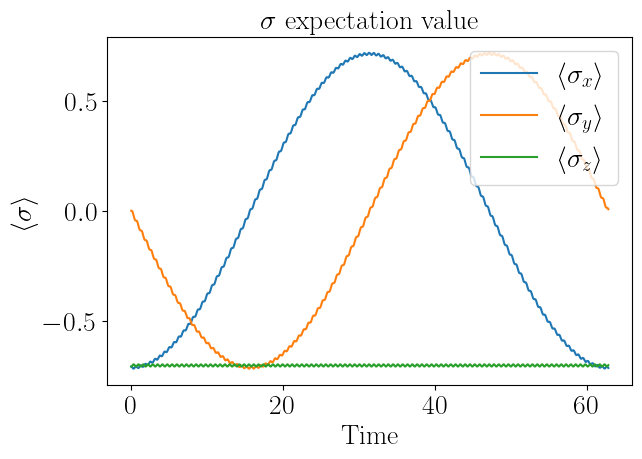

In [307]:
theta=np.pi/4#np.pi/4
Omega=0.1
omega0=10
tmax=2*np.pi/(Omega if Omega!=0 else omega0)
nsteps=2001

st, ct = np.sin(theta), np.cos(theta)
def H_of_t(t):
    nx = st * np.cos(Omega * t)
    ny = st * np.sin(Omega * t)
    nz = ct
    return 0.5 * omega0 * (nx * Pauli.sx + ny * Pauli.sy + nz * Pauli.sz)

def jumps_of_t(t):
    return [Jump(Pauli.sm, 0.0)] #No jumps, just passive evolution

model = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
evolver = LindbladEvolver(model, builder)

# Time grid
t = np.linspace(0.0, float(tmax), int(nsteps))

# Evolve
#Start in ground state of H(0)
H0= H_of_t(0.0)
w, v = np.linalg.eigh(H0)
psi_g = v[:, np.argmin(w)]   # ground (for omega0>0)
rho0 = pure_rho(psi_g)
#rho0= pure_rho(np.array([1.0, 0.0]), normalize=True)  # start in |0>
traj = evolver.simulate(rho0, t)

# Bloch vector time series
s_t = np.array([bloch(traj.rho(k)) for k in range(len(traj.t))])  # (nt,3)

set_font(20)
set_fig(2.0, 1.5)
plt.title(r"$\sigma$ expectation value")
plt.plot(t, s_t)
plt.legend([r"$\langle \sigma_x \rangle$", r"$\langle \sigma_y \rangle$", r"$\langle \sigma_z \rangle$"], loc="upper right")
plt.xlabel("Time")
plt.ylabel(r"$\langle \sigma \rangle$")


### Checking that there is the Berry phase

In [308]:
def psi_from_rho(rho):
    # dominant eigenvector of rho (rank-1 for unitary evolution)
    w, v = np.linalg.eigh(rho)
    psi = v[:, np.argmax(w)]
    # fix a smooth gauge: make overlap with previous step positive real later (handled below)
    return psi

def geometric_phase_from_traj(traj, H_of_t):
    t = traj.t
    dt = np.diff(t)

    # reconstruct |psi(t_k)>
    psis = []
    for k, tk in enumerate(t):
        rho = traj.rho(k)
        psi = psi_from_rho(rho)
        psis.append(psi)
    psis = np.array(psis)  # (nt,2)

    # gauge-fix: enforce <psi_k|psi_{k+1}> to have positive real part (smooth phase)
    for k in range(len(t)-1):
        ov = np.vdot(psis[k], psis[k+1])
        if ov == 0:
            continue
        psis[k+1] *= np.exp(-1j * np.angle(ov))

    # total phase from endpoint overlap
    phi_tot = np.angle(np.vdot(psis[0], psis[-1]))

    # dynamical phase: -∫ <H> dt
    E = np.array([np.real(np.vdot(psis[k], H_of_t(t[k]) @ psis[k])) for k in range(len(t))])
    # trapezoid
    phi_dyn = -np.sum(0.5*(E[:-1] + E[1:]) * dt)

    gamma = (phi_tot - phi_dyn + np.pi) % (2*np.pi) - np.pi  # wrap to (-pi,pi]
    return gamma, phi_tot, phi_dyn

gamma, phi_tot, phi_dyn = geometric_phase_from_traj(traj, H_of_t)
print("gamma =", gamma)
print("gamma (theory)", np.pi * (1.0 - np.cos(theta)))

gamma = 0.9597320663809548
gamma (theory) 0.92015118451061


# Testing that things work

## Finding left and right eigenvectors

In [162]:
def H_of_t(t):
        return 0.5 * omega * Pauli.sz

def jumps_of_t(t):
    eps = 0.3
    gam = 0.01
    return [Jump(Pauli.sm, eps), Jump(Pauli.sx, gam)]

model = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)

L=builder.build(model.H(0.0), model.jumps(0.0))
print(L)

2
[[-0.31+0.j  0.  +0.j  0.  +0.j  0.01+0.j]
 [ 0.  +0.j -0.16+1.j  0.01+0.j  0.  +0.j]
 [ 0.  +0.j  0.01+0.j -0.16-1.j  0.  +0.j]
 [ 0.31+0.j  0.  +0.j  0.  +0.j -0.01+0.j]]


In [165]:
def vec(A):   return A.reshape(-1, order="F")
def unvec(v): return v.reshape((2,2), order="F")

B = [Pauli.I2, Pauli.sx, Pauli.sy, Pauli.sz]  # Pauli operator basis


def liouvillian_to_bloch_matrix(L):
    # coefficients u=(u0,u1,u2,u3) with rho = 0.5 * sum u_mu B_mu, and u0=Tr(rho)=1
    M = np.zeros((4,4), dtype=complex)
    for mu in range(4):
        rho_mu = 0.5 * B[mu]
        drho = unvec(L @ vec(rho_mu))
        for nu in range(4):
            M[nu, mu] = np.trace(B[nu] @ drho)   # du_nu/dt when u_mu=1
    return M

M = liouvillian_to_bloch_matrix(L)
print(M)

[[ 0.  +0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j -0.15+0.j -1.  +0.j  0.  +0.j]
 [ 0.  +0.j  1.  +0.j -0.17+0.j  0.  +0.j]
 [-0.3 +0.j  0.  +0.j  0.  +0.j -0.32+0.j]]


In [ ]:
class AGP:
    """
    Utility methods for computing AGP-like quantities.
    Keep this isolated: handles biorthogonal normalization and gap safeguards.
    """
    def __init__(self, gap_tol: float = 1e-10):
        self.gap_tol = float(gap_tol)

    def biorthogonal_eigs(self, L: np.ndarray):
        # Right eigs: L R = λ R
        evals, R = np.linalg.eig(L) 

        # Left eigs: L^† Lleft = λ* Lleft  <=> (L^†) V = λ* V
        evalsL, V = np.linalg.eig(L.conj().T)

        # Match eigenvalues by closest conjugate for left and right eigenvecs
        Lleft = np.zeros_like(R)
        for i, lam in enumerate(evals):
            j = int(np.argmin(np.abs(evalsL - lam.conjugate())))
            Lleft[:, i] = V[:, j]

        # Biorthonormalize: Lleft^† R = I
        M = Lleft.conj().T @ R
        Minv = np.linalg.inv(M)
        Rn = R @ Minv
        # then Lleft stays as is, but now Lleft^† Rn = I
        return evals, Rn, Lleft

    def offdiag_from_dL(self, evals, R, Lleft, dL):
        """
        Off-diagonal AGP elements in eigenbasis:
          A_{ab} = <L_a| dR_b> = <L_a| dL |R_b> / (λ_b - λ_a), a!=b
        Returns A in that eigenbasis.
        """
        n = len(evals)
        A = np.zeros((n, n), dtype=np.complex128)
        for a in range(n):
            for b in range(n):
                if a == b:
                    continue
                denom = (evals[b] - evals[a])
                if abs(denom) < self.gap_tol:
                    A[a, b] = np.nan  # signal singular/EP/degeneracy
                    continue
                num = (Lleft[:, a].conj().T @ (dL @ R[:, b]))
                A[a, b] = num / denom
        return A

In [ ]:
try:
    from scipy.optimize import linear_sum_assignment
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
def run_2ls_lindblad_mode_protocol_time_dependent(
    tmax: float,
    epsilon_of_t,
    gamma_of_t,
    *,
    nsteps: int = 401,
    rho0=None,
    omega: float = 1.0,
    dim: int = 2,
    vec_order: str = "F",
    do_plot: bool = True,
    modes: list[int] | None = None,
    eps_norm: float = 1e-15,
    occupation: str = "frac",   # NEW: "frac" or "abs"
):
    """
    Time-dependent mode decomposition with mode tracking:
      - evolve rho(t)
      - at each t_k diagonalise L(t_k) -> (evals_k, W_k, R_k) biorth basis
      - track labels by maximizing |W_prev† R_new| via assignment
      - coefficients: c_k = W_k† vec(rho_k)
      - occupation:
           "frac": |c_kj| / sum_m |c_km|
           "abs" : |c_kj|
    """
    if rho0 is None:
        rho0 = pure_rho(np.array([1.0/np.sqrt(2), 1.0/np.sqrt(2)]), normalize=True)

    def H_of_t(t): return 0.5 * omega * Pauli.sz
    def jumps_of_t(t):
        return [Jump(Pauli.sm, float(epsilon_of_t(t))), Jump(Pauli.sx, float(gamma_of_t(t)))]

    model   = LindbladModel2LS(H_of_t, jumps_of_t)
    builder = LiouvillianBuilder(dim=dim, vec_order=vec_order)
    evolver = LindbladEvolver(model, builder)

    t = np.linspace(0.0, float(tmax), int(nsteps))
    traj = evolver.simulate(rho0, t)

    nt = len(t)
    n  = dim * dim
    coeffs  = np.zeros((nt, n), dtype=np.complex128)
    evals_t = np.zeros((nt, n), dtype=np.complex128)

    def match_perm(W_prev, R_new):
        O = np.abs(W_prev.conj().T @ R_new)  # (n,n)
        if _HAS_SCIPY:
            row, col = linear_sum_assignment(-O)
            perm = col[np.argsort(row)]
            return perm
        perm = np.empty(n, dtype=int)
        used = np.zeros(n, dtype=bool)
        for i in range(n):
            j = int(np.argmax(np.where(used, -np.inf, O[i, :])))
            perm[i] = j
            used[j] = True
        return perm

    W_prev = None
    for k, tk in enumerate(t):
        Lk = builder.build(model.H(tk), model.jumps(tk))
        bi = Biorth.compute(Lk)
        Wk, Rk, evals = bi.W, bi.R, bi.evals

        if W_prev is not None:
            perm = match_perm(W_prev, Rk)
            Wk    = Wk[:, perm]
            Rk    = Rk[:, perm]
            evals = evals[perm]

        evals_t[k, :] = evals
        coeffs[k, :]  = traj.rho_vec[k, :] @ Wk.conj()
        W_prev = Wk

    absC = np.abs(coeffs)

    if occupation.lower() in ("frac", "fraction", "sum"):
        denom = np.maximum(absC.sum(axis=1, keepdims=True), eps_norm)
        occ = absC / denom
        occ_label = r"$|c_j|/\sum_k |c_k|$"
        ylab = "Fractional occupation"
    elif occupation.lower() in ("abs", "ci", "raw"):
        occ = absC
        occ_label = r"$|c_j|$"
        ylab = "Mode amplitude"
    else:
        raise ValueError(f"occupation must be 'frac' or 'abs', got {occupation!r}")

    if modes is None:
        modes = list(range(n))

    if do_plot:
        set_font(20)
        set_fig(2.3, 1.6)
        plt.title("Instantaneous mode occupations (tracked)")

        for j in modes:
            if occupation.lower() in ("frac", "fraction", "sum"):
                lab = fr"$|c_{j}|/\sum_k |c_k|$"
            else:  # "abs"/"raw"
                lab = fr"$|c_{j}|$"
            plt.plot(t, occ[:, j], label=lab)

    plt.xlabel("Time")
    plt.ylabel("Fractional occupation" if occupation.lower() in ("frac","fraction","sum") else "Mode amplitude")
    plt.legend(loc="upper right")

    # return occ in place of frac to avoid confusion, but keep old name if you prefer
    return t, traj, occ, coeffs, evals_t

# Testing ground

## Checking CCP

In [193]:
def op_basis(dim: int):
    """Matrix units E_{mn} with (E_{mn})_{ab} = δ_{am} δ_{bn}."""
    basis = []
    for m in range(dim):
        for n in range(dim):
            E = np.zeros((dim, dim), dtype=np.complex128)
            E[m, n] = 1.0
            basis.append(((m, n), E))
    return basis


#Finding the choi matrix of a given superoperator
def choi_from_superop(S: np.ndarray, *, dim: int, builder):
    """
    Build Choi matrix J of the channel (Phi) represented by superoperator S acting as vec(ρ') = S vec(ρ).
    Uses definition: J = sum_{mn} Phi(E_{mn}) ⊗ E_{mn}.
    Returns J as (d^2,d^2) complex array.
    """
    
    d = dim
    J = np.zeros((d*d, d*d), dtype=np.complex128)
    for (m, n), Emn in op_basis(d):
        out = builder.mat(S @ builder.vec(Emn))  # E(Emn)
        # add kron(out, Emn)
        J += np.kron(out, Emn) #Take the tensor product with the projector part again
    return J

#Choi sandwiched between projectors onto orthogonal to maximally entangled state
def CCP_matrix(J,dim):
    d = dim
    # Define the maximally entangled state |Φ⟩ = (1/√d) ∑_i |i⟩ ⊗ |i⟩ 
    phi = np.zeros((d*d,), dtype=np.complex128)
    for i in range(d):
        phi[i*d + i] = 1.0 / np.sqrt(d)
    # Projector onto |Φ⟩, max entangled state
    P_phi = np.outer(phi, phi.conj())
    
    # Projector onto the orthogonal complement of |Φ⟩
    P_orth = np.eye(d*d) - P_phi
    # Sandwiched Choi matrix
    J_CCP = P_orth @ J @ P_orth
    return J_CCP




#Writing code to check if a given matrix is CCP
def check_PSD(J: np.ndarray, *, tol: float = 1e-10):
    """Completely positive iff Choi matrix is PSD."""
    # Symmetrize to reduce tiny numerical non-Hermiticity
    JH = 0.5 * (J + J.conj().T) #Should be the form of a density matrix, Hermitian.
    w = np.linalg.eigvalsh(JH)
    min_eig = float(np.min(w))
    return (min_eig >= -tol), min_eig


In [216]:
gamma=0.5

def mx(t):
    return 1-t

def my(t):
    return 0

def mz(t):
    return t/150

# model to study
def H_of_t(t):
    return mx(t) * Pauli.sx + my(t) * Pauli.sy + mz(t) * Pauli.sz

def jumps_of_t(t):
    return [Jump(Pauli.sm, 2*gamma)]

model = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=2, vec_order="F")
evolver = LindbladEvolver(model, builder)

#get the instantaneous steady state
def rhoss(builder, model, t):
    L = builder.build(model.H(t), model.jumps(t))
    evals, R = np.linalg.eig(L)
    idx = np.argmin(np.abs(evals))
    rho_ss_vec = R[:, idx]
    rho_ss = builder.mat(rho_ss_vec)
    return rho_ss/np.trace(rho_ss) #Return the trace normalised version

def drhossdt(builder, model, t, dt=1e-6):
    L_plus = builder.build(model.H(t+dt), model.jumps(t+dt))
    L_minus = builder.build(model.H(t-dt), model.jumps(t-dt))
    rho_plus = rhoss(builder, model, t+dt)
    rho_minus = rhoss(builder, model, t-dt)
    drho_dt = (rho_plus - rho_minus) / (2*dt)
    return drho_dt


t0=0.2
print(get_steady_state(builder, model, t=t0))

#The lower left element should be given by this analytical solution
print(-(mx(t0)+1.j*my(t0))*(2*mz(t0)-1.j*gamma)/(2*(mx(t0)**2+my(t0)**2+2*mz(t0)**2)+gamma**2))


#Calculate the AGP superoperator for the SS at time t
def AGP0(builder, model, t, dt=1e-6):
    rho_ss = rhoss(builder, model, t)
    drho_dt = drhossdt(builder, model, t, dt)

    #Unfold the matrices into supervectors
    rho_ss_vec = builder.vec(rho_ss)
    drho_dt_vec = builder.vec(drho_dt)

    #calculate part of the AGP superoperator
    Avec = -1/2*(rho_ss_vec*np.trace(drho_dt) - drho_dt_vec)
    Z = np.zeros_like(Avec)       # shape (4,)

    return np.column_stack([Avec, Z, Z, Avec]) #4x4 superoperator matrix.

t0=1.0
v=AGP0(builder, model, t0)
print("AGP superoperator at t =", t0)
print(np.round(v,4))
print(1/2*drhossdt(builder, model, t0))

J=choi_from_superop(v, dim=2, builder=builder)
JC=CCP_matrix(J, dim=2)
ok_CCP, min_eig = check_PSD(JC)
print("Is the AGP superoperator CCP?", ok_CCP)
print("Minimum eigenvalue of the CCP matrix:", min_eig)

2
[[ 0.41829871+1.72089623e-17j -0.00139433-2.61436693e-01j]
 [-0.00139433+2.61436693e-01j  0.58170129-1.72089623e-17j]]
(-0.0013943290314409578+0.26143669339517955j)
AGP superoperator at t = 1.0
[[-0.    -0.j      0.    +0.j      0.    +0.j     -0.    -0.j    ]
 [ 0.0266-0.9993j  0.    +0.j      0.    +0.j      0.0266-0.9993j]
 [ 0.0266+0.9993j  0.    +0.j      0.    +0.j      0.0266+0.9993j]
 [ 0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]]
[[-2.96397393e-15-3.92704740e-18j  2.66477172e-02+9.99289394e-01j]
 [ 2.66477172e-02-9.99289394e-01j  0.00000000e+00+3.92704740e-18j]]
Is the AGP superoperator CCP? False
Minimum eigenvalue of the CCP matrix: -0.9996446339270324


In [212]:
np.trace(drhossdt(builder, model, t0))

(-5.927947854595792e-15+0j)

In [ ]:
L = builder.build(model.H(0.0), model.jumps(0.0))


print(L)
evals, R=np.linalg.eig(L)
print(evals[2])
R[:,2]#/np.exp(1j*np.angle(R[:,2]))

rho0=np.reshape(R[:,2], (2,2), order="F")
rho0/np.trace(rho0)

[[-1. +0.j  0. -1.j  0. +1.j  0. +0.j]
 [ 0. -1.j -0.5+0.j  0. +0.j  0. +1.j]
 [ 0. +1.j  0. +0.j -0.5+0.j  0. -1.j]
 [ 1. +0.j  0. +1.j  0. -1.j  0. +0.j]]
(-5.82699098150123e-17+1.2956657038396355e-16j)


array([[ 4.44444444e-01+8.27135999e-18j, -1.29669101e-16-2.22222222e-01j],
       [-2.32701727e-16+2.22222222e-01j,  5.55555556e-01-8.27135999e-18j]])

In [145]:
(gamma)/(2+gamma**2)

0.2222222222222222

In [88]:
gamma=0.5

def mx(t):
    return 1

def my(t):
    return 0

def mz(t):
    return t/150

# model to study
def H_of_t(t):
    return mx(t) * Pauli.sx + my(t) * Pauli.sy + mz(t) * Pauli.sz

def jumps_of_t(t):
    return [Jump(Pauli.sm, 2*t)]

model = LindbladModel2LS(H_of_t, jumps_of_t)
builder = LiouvillianBuilder(dim=2, vec_order="F")
evolver = LindbladEvolver(model, builder)

#get the instantaneous steady state
t=np.arange(0.0, 201, 0.1)
n_ss_t=get_steady_state_blochvector_of_t(builder, model, t)



2


In [101]:
nhat = normalize_rows(n_ss_t)  # normalised Bloch vectors
nhatdot = derivative_unit_vectors_uniform(nhat, t[1]-t[0])  # time derivatives of unit vectors

Omega=np.cross(nhat[2], nhatdot[2])
Omega
bloch_to_operator(Omega)


array([[ 1.08774751e-13+0.j        , -4.94455071e-01+0.00659273j],
       [-4.94455071e-01-0.00659273j, -1.08774751e-13+0.j        ]])

In [84]:
def plot_bloch_trajectory_colored(n_t, t, elev=20, azim=35, figsize=(7, 7), title="Bloch vector trajectory"):
    t = np.asarray(t)

    x, y, z = n_t[:, 0], n_t[:, 1], n_t[:, 2]

    u = np.linspace(0, 2*np.pi, 120)
    v = np.linspace(0, np.pi, 60)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(xs, ys, zs, alpha=0.12, linewidth=0)
    ax.plot_wireframe(xs, ys, zs, rstride=10, cstride=10, alpha=0.2)

    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    sc = ax.scatter(x, y, z, c=t, s=16)
    ax.plot(x, y, z, lw=1, alpha=0.6)

    ax.scatter(x[0], y[0], z[0], s=60, label="start")
    ax.scatter(x[-1], y[-1], z[-1], s=60, marker="^", label="end")

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_zlim(-1.05, 1.05)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)
    ax.legend()

    cbar = plt.colorbar(sc, ax=ax, pad=0.08)
    cbar.set_label("time")

    plt.tight_layout()
    plt.show()

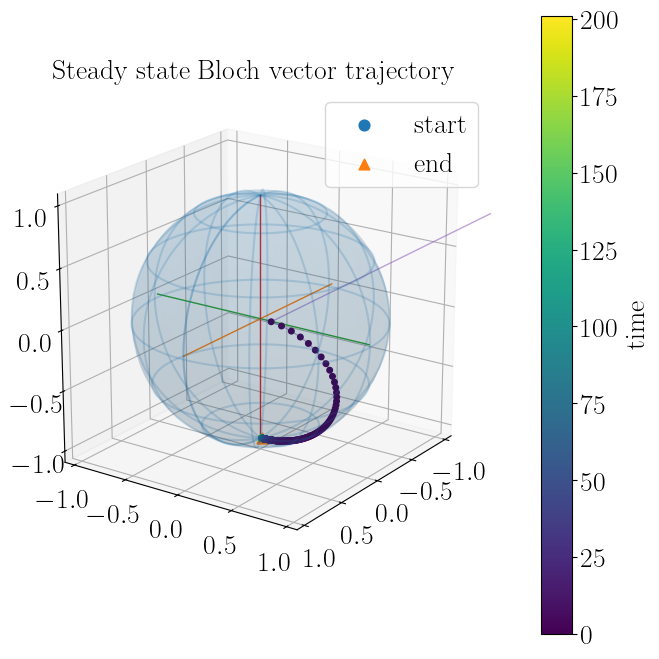

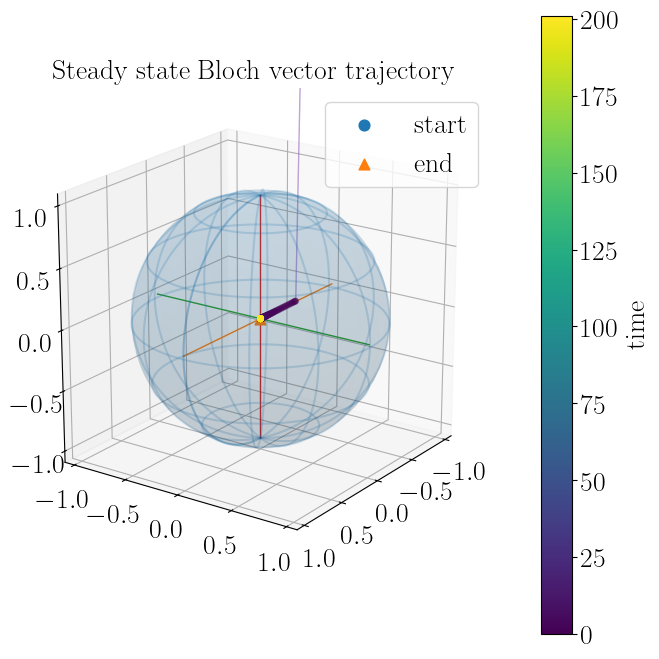

In [94]:
plot_bloch_trajectory_colored(n_ss_t, t, title="Steady state Bloch vector trajectory")
plot_bloch_trajectory_colored(Omega, t, title="Steady state Bloch vector trajectory")

In [115]:
def plot_bloch_sphere_comparison(
    s_t_orig,
    s_t_cd,
    s_t_iss,
    t=None,
    *,
    normalize=False,
    elev=20,
    azim=35,
    figsize=(7, 7),
    title="Bloch-sphere trajectory: original vs CD vs ISS",
):
    """
    Plot original, CD, and instantaneous-steady-state trajectories on/in the Bloch sphere.

    Parameters
    ----------
    s_t_orig : array, shape (Nt, 3)
        Original evolution Bloch vectors.
    s_t_cd : array, shape (Nt, 3)
        CD evolution Bloch vectors.
    s_t_iss : array, shape (Nt, 3)
        Instantaneous steady-state Bloch vectors.
    t : array, shape (Nt,), optional
        Time array used to color the scatter points.
    normalize : bool
        If True, project all trajectories onto the unit sphere.
        If False, plot the true Bloch vectors, including purity changes inside the sphere.
    """

    s_t_orig = np.asarray(s_t_orig, dtype=float)
    s_t_cd = np.asarray(s_t_cd, dtype=float)
    s_t_iss = np.asarray(s_t_iss, dtype=float)

    if normalize:
        s_t_orig = normalize_rows(s_t_orig)
        s_t_cd = normalize_rows(s_t_cd)
        s_t_iss = normalize_rows(s_t_iss)

    if t is None:
        t = np.arange(len(s_t_orig))
    else:
        t = np.asarray(t)

    # Bloch sphere mesh
    u = np.linspace(0, 2*np.pi, 120)
    v = np.linspace(0, np.pi, 60)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    # Sphere
    ax.plot_surface(xs, ys, zs, alpha=0.10, linewidth=0)
    ax.plot_wireframe(xs, ys, zs, rstride=10, cstride=10, alpha=0.20)

    # Axes
    ax.plot([-1, 1], [0, 0], [0, 0], lw=1, alpha=0.7)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1, alpha=0.7)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1, alpha=0.7)

    ax.text(1.08, 0, 0, r"$x$", fontsize=12)
    ax.text(0, 1.08, 0, r"$y$", fontsize=12)
    ax.text(0, 0, 1.08, r"$z$", fontsize=12)

    # Curves
    ax.plot(
        s_t_orig[:, 0],
        s_t_orig[:, 1],
        s_t_orig[:, 2],
        lw=2,
        label="original",
    )

    ax.plot(
        s_t_cd[:, 0],
        s_t_cd[:, 1],
        s_t_cd[:, 2],
        "--",
        lw=2,
        label="CD",
    )

    ax.plot(
        s_t_iss[:, 0],
        s_t_iss[:, 1],
        s_t_iss[:, 2],
        ":",
        lw=2.5,
        label="ISS target",
    )

    # Colored scatter overlays by time
    sc = ax.scatter(
        s_t_cd[:, 0],
        s_t_cd[:, 1],
        s_t_cd[:, 2],
        c=t,
        s=12,
        alpha=0.75,
    )

    # Start/end markers
    ax.scatter(*s_t_orig[0], s=60, marker="o", label="orig start")
    ax.scatter(*s_t_orig[-1], s=60, marker="^", label="orig end")

    ax.scatter(*s_t_cd[0], s=60, marker="o", label="CD start")
    ax.scatter(*s_t_cd[-1], s=60, marker="^", label="CD end")

    ax.scatter(*s_t_iss[0], s=70, marker="x", label="ISS start")
    ax.scatter(*s_t_iss[-1], s=70, marker="X", label="ISS end")

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_zlim(-1.05, 1.05)

    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)

    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_zticks([-1, 0, 1])

    ax.set_xlabel(r"$\langle\sigma_x\rangle$")
    ax.set_ylabel(r"$\langle\sigma_y\rangle$")
    ax.set_zlabel(r"$\langle\sigma_z\rangle$")

    ax.set_title(title)

    cbar = plt.colorbar(sc, ax=ax, pad=0.08)
    cbar.set_label("time")

    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0))
    plt.tight_layout()
    plt.show()

In [ ]:
# Stable derivative of n_ss_t w.r.t. t (use Savitzky–Golay if available, otherwise gradient)
try:
    from scipy.signal import savgol_filter
    # choose an odd window <= len(t)
    win = 11
    if win > len(t):
        win = len(t) if len(t) % 2 == 1 else len(t) - 1
    if win < 5:
        win = 5 if 5 % 2 == 1 else 6
    dn_ss_dt = savgol_filter(n_ss_t, win, 3, deriv=1, delta=(t[1]-t[0]), mode='interp')
except Exception:
    # fallback: central differences
    dn_ss_dt = np.gradient(n_ss_t, t)

# dn_ss_dt now holds d(n_ss_t)/dt on the same grid `t`.
